In [ ]:
import sys
from pathlib import Path

# Ensure project root is on sys.path so local modules (common, etc.) can be imported
_project_root = str(Path(__file__).resolve().parent.parent) if "__file__" in dir() else str(Path.cwd().parent)
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)

import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

from common import evaluations_dir, features_dir

# Consolidated gap-analysis utilities (extracted from this notebook)
from figures_paper.gap_analysis import (
    build_annotation_specs,
    compute_gap_per_cell_line,
    compute_rmse_per_cell_line,
    correlate_gap_vs_markers,
    detect_heatmap_outliers,
    load_all_marker_data,
    marker_obs_correlation_heatmap,
    outliers_from_dendrogram,
    plot_gap_on_pca,
    plot_heatmap,
    scatter_gap_vs_rmse,
    scatter_generalisation_gap,
)

In [58]:
# Configuration
data = "dream_cytof"
figure = "figure5"
models = {
    "tegfr": "EGFR_MAPK__logobs_tegfr_aggavg",
}

# Load by_cl_cond_obs for both models
# Note: "sample" = cell line, "samples" = CV split
by_dfs = {}
for label, model in models.items():
    path = evaluations_dir / model / data / f"by_cl_cond_obs_{figure}.csv"
    df = pd.read_csv(path, index_col=0).rename(columns={"sample": "cell_line"})
    df["model_label"] = label
    by_dfs[label] = df
    print(f"[{label}] Loaded {len(df)} rows, {df['cell_line'].nunique()} cell lines — refs: {sorted(df['ref'].unique())}, contexts: {sorted(df['context'].dropna().unique())}")

# Combined DataFrame
by_df = pd.concat(by_dfs.values(), ignore_index=True)

[tegfr] Loaded 577035 rows, 63 cell lines — refs: ['DMM', 'avg_model', 'elasticnet', 'lasso', 'linreg', 'sample'], contexts: ['cytof_init']


In [59]:
# Build cell-line annotations + colour palettes for heatmap row colours.
# All palette dicts and subtype lookups are built inside build_annotation_specs.
_all_cell_lines = sorted(by_df["cell_line"].unique())

ANNOTATION_SPECS = build_annotation_specs(_all_cell_lines, file_dir=features_dir)

# Retrieve cellosaurus objects stashed by build_annotation_specs (used later)
cello_annot = ANNOTATION_SPECS.pop("_cello_annot")
cello_modality = ANNOTATION_SPECS.pop("_cello_modality")

# Report coverage
for name in ANNOTATION_SPECS:
    lookup, _ = ANNOTATION_SPECS[name]
    n = sum(1 for c in _all_cell_lines if c in lookup)
    print(f"  {name:10s}: {n}/{len(_all_cell_lines)} cell lines")

  PAM50     : 52/63 cell lines
  Lum/Bas   : 52/63 cell lines
  Receptor  : 63/63 cell lines
  Intrinsic : 63/63 cell lines
  Claudin   : 63/63 cell lines
  Neve      : 63/63 cell lines
  Site      : 63/63 cell lines
  pERBB2    : 63/63 cell lines
  TP53      : 63/63 cell lines
  PIK3CA    : 63/63 cell lines
  CDH1      : 63/63 cell lines
  PTEN      : 63/63 cell lines


In [60]:
# Identify the best linear regressor per (model_label, context) based on lowest mean RMSE on train
REGRESSION_MODES = ["linreg", "lasso", "elasticnet"]

reg_df = by_df[by_df["ref"].isin(REGRESSION_MODES)]
best_reg = (
    reg_df[reg_df["dataset"] == "train"]
    .groupby(["model_label", "context", "ref"])
    .agg(mean_rmse=("rmse", "mean"))
    .reset_index()
    .sort_values("mean_rmse")
    .groupby(["model_label", "context"])
    .first()
    .reset_index()
    .rename(columns={"ref": "best_ref"})
    [["model_label", "context", "best_ref"]]
)
print("Best regressor per model × context:")
print(best_reg.to_string(index=False))

Best regressor per model × context:
model_label    context best_ref
      tegfr cytof_init   linreg


In [61]:
# Compute generalisation gap for DMM
dmm_gap = compute_gap_per_cell_line(by_df, by_df["ref"] == "DMM", "DMM")

# Compute generalisation gap for best regressor per (model_label, context)
reg_gap_parts = []
for _, row in best_reg.iterrows():
    ml, ctx, ref = row["model_label"], row["context"], row["best_ref"]
    mask = (by_df["ref"] == ref) & (by_df["context"] == ctx) & (by_df["model_label"] == ml)
    part = compute_gap_per_cell_line(by_df, mask, "Regression")
    reg_gap_parts.append(part)
reg_gap = pd.concat(reg_gap_parts, ignore_index=True)

# Merge DMM and regression gaps
merged = pd.merge(
    dmm_gap[["cell_line", "model_label", "context", "gap"]].rename(columns={"gap": "gap_dmm"}),
    reg_gap[["cell_line", "model_label", "context", "gap"]].rename(columns={"gap": "gap_regression"}),
    on=["cell_line", "model_label", "context"],
    how="inner",
)
print(f"Merged: {len(merged)} cell line × model × context combinations")
merged.head()

Merged: 58 cell line × model × context combinations


dataset,cell_line,model_label,context,gap_dmm,gap_regression
0,c184A1,tegfr,cytof_init,0.030527,0.031512
1,c184B5,tegfr,cytof_init,0.031537,0.074970
2,cAU565,tegfr,cytof_init,0.049704,0.094441
3,cBT20,tegfr,cytof_init,0.066379,0.072901
4,cBT474,tegfr,cytof_init,0.127679,0.128894


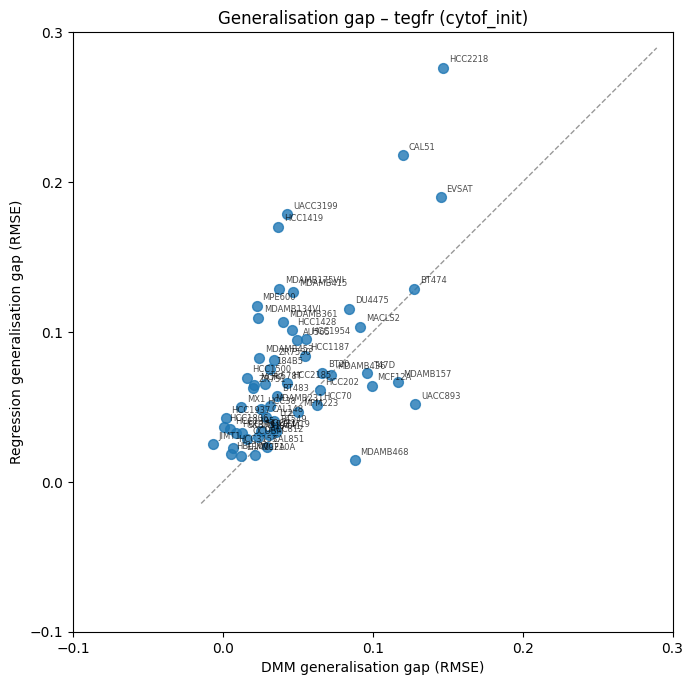

In [62]:
# Per model × context
for ml in sorted(merged["model_label"].unique()):
    for ctx in sorted(merged[merged["model_label"] == ml]["context"].unique()):
        ml_ctx_df = merged[(merged["model_label"] == ml) & (merged["context"] == ctx)]
        fig, ax = scatter_generalisation_gap(ml_ctx_df, context=ctx)
        ax.set_title(f"Generalisation gap – {ml} ({ctx})")
        plt.show()

## Generalisation gap vs overall RMSE

Load per-cell-line RMSE from the `all` split (figure5, trained on
all cell lines) and compare against the LOOCV generalisation gap (figure5).
This reveals whether cell lines that are harder to fit also generalise worse.

In [63]:
# Load the "all" split from figure5 to get per-cell-line RMSE
# when the model is trained on ALL cell lines (no held-out set)
all_split = "all"
figure_all = "figure5"

all_dfs = {}
for label, model_name in models.items():
    path_all = evaluations_dir / model_name / data / f"by_cl_cond_obs_{figure_all}.csv"
    df_all = pd.read_csv(path_all, index_col=0).rename(columns={"sample": "cell_line"})
    # Keep only the all split
    df_all = df_all[df_all["samples"] == all_split].copy()
    df_all["model_label"] = label
    all_dfs[label] = df_all
    print(f"[{label}] Loaded {len(df_all)} rows from {figure_all}/{all_split}, "
          f"{df_all['cell_line'].nunique()} cell lines, "
          f"datasets: {sorted(df_all['dataset'].unique())}, "
          f"refs: {sorted(df_all['ref'].unique())}")

all_df = pd.concat(all_dfs.values(), ignore_index=True)
print(f"\nCombined: {len(all_df)} rows")

[tegfr] Loaded 10665 rows from figure5/all, 63 cell lines, datasets: ['train', 'val'], refs: ['DMM', 'avg_model', 'elasticnet', 'lasso', 'linreg', 'sample']

Combined: 10665 rows


In [64]:
# compute_rmse_per_cell_line imported from gap_analysis

# DMM RMSE from "all" split
dmm_rmse = compute_rmse_per_cell_line(all_df, all_df["ref"] == "DMM", "DMM")
dmm_rmse = dmm_rmse.rename(columns={"mean_rmse": "rmse_all_dmm"})

# Best regressor RMSE from "all" split
reg_rmse_parts = []
for _, row in best_reg.iterrows():
    ml, ctx, best_ref = row["model_label"], row["context"], row["best_ref"]
    mask = (all_df["ref"] == best_ref) & (all_df["context"] == ctx) & (all_df["model_label"] == ml) & (all_df["dataset"] == "train")
    part = compute_rmse_per_cell_line(all_df, mask, "Regression")
    reg_rmse_parts.append(part)
reg_rmse = pd.concat(reg_rmse_parts, ignore_index=True)
reg_rmse = reg_rmse.rename(columns={"mean_rmse": "rmse_all_reg"})

# Merge RMSE (from "all") with gap (from LOOCV)
gap_vs_rmse = merged.copy()
gap_vs_rmse = gap_vs_rmse.merge(
    dmm_rmse[["cell_line", "model_label", "context", "rmse_all_dmm"]],
    on=["cell_line", "model_label", "context"], how="inner",
)
gap_vs_rmse = gap_vs_rmse.merge(
    reg_rmse[["cell_line", "model_label", "context", "rmse_all_reg"]],
    on=["cell_line", "model_label", "context"], how="inner",
)
print(f"gap_vs_rmse: {len(gap_vs_rmse)} rows")
gap_vs_rmse.head()

gap_vs_rmse: 58 rows


,cell_line,model_label,context,gap_dmm,gap_regression,rmse_all_dmm,rmse_all_reg
0,c184A1,tegfr,cytof_init,0.030527,0.031512,0.365487,0.333299
1,c184B5,tegfr,cytof_init,0.031537,0.074970,0.466723,0.420350
2,cAU565,tegfr,cytof_init,0.049704,0.094441,0.388402,0.528911
3,cBT20,tegfr,cytof_init,0.066379,0.072901,0.415425,0.533167
4,cBT474,tegfr,cytof_init,0.127679,0.128894,0.369431,0.336062


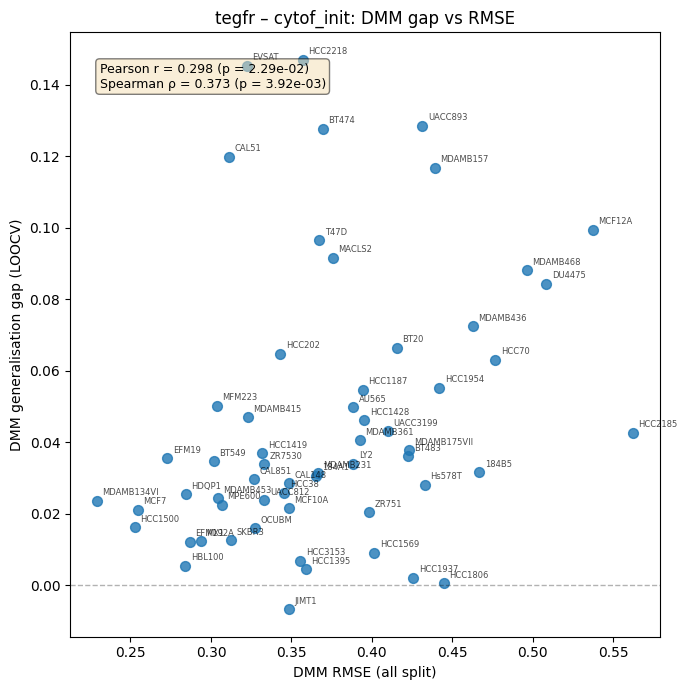

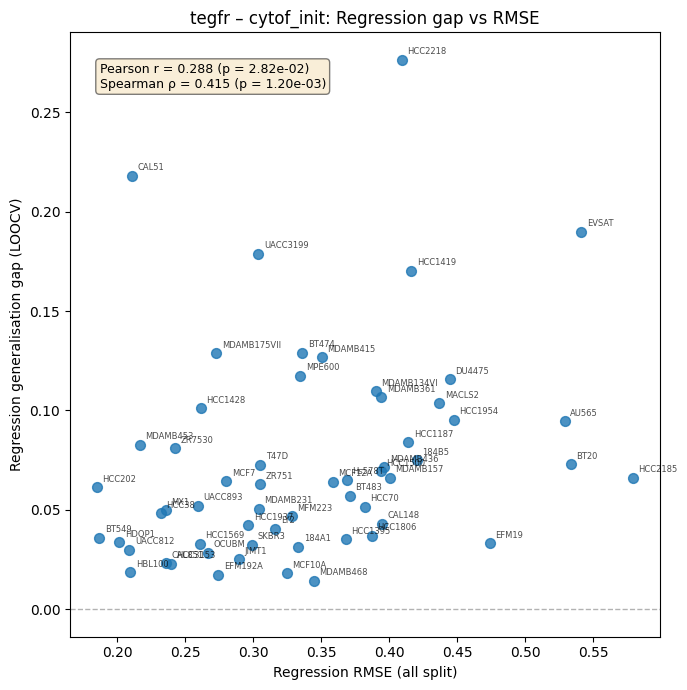

In [65]:
# Plot gap vs RMSE for each model × context × method
for ml in sorted(gap_vs_rmse["model_label"].unique()):
    for ctx in sorted(gap_vs_rmse[gap_vs_rmse["model_label"] == ml]["context"].unique()):
        subset = gap_vs_rmse[(gap_vs_rmse["model_label"] == ml) & (gap_vs_rmse["context"] == ctx)]
        for method in ["dmm", "regression"]:
            fig, ax = scatter_gap_vs_rmse(subset, method=method, context=ctx)
            ax.set_title(f"{ml} – {ctx}: {'DMM' if method == 'dmm' else 'Regression'} gap vs RMSE")
            plt.show()

## Generalisation gap heatmaps

Clustered heatmap of per-cell-line × (condition, observable) generalisation gap
(val RMSE − train RMSE). Rows = cell lines, columns = condition/observable pairs.


Model: tegfr, Context: cytof_init


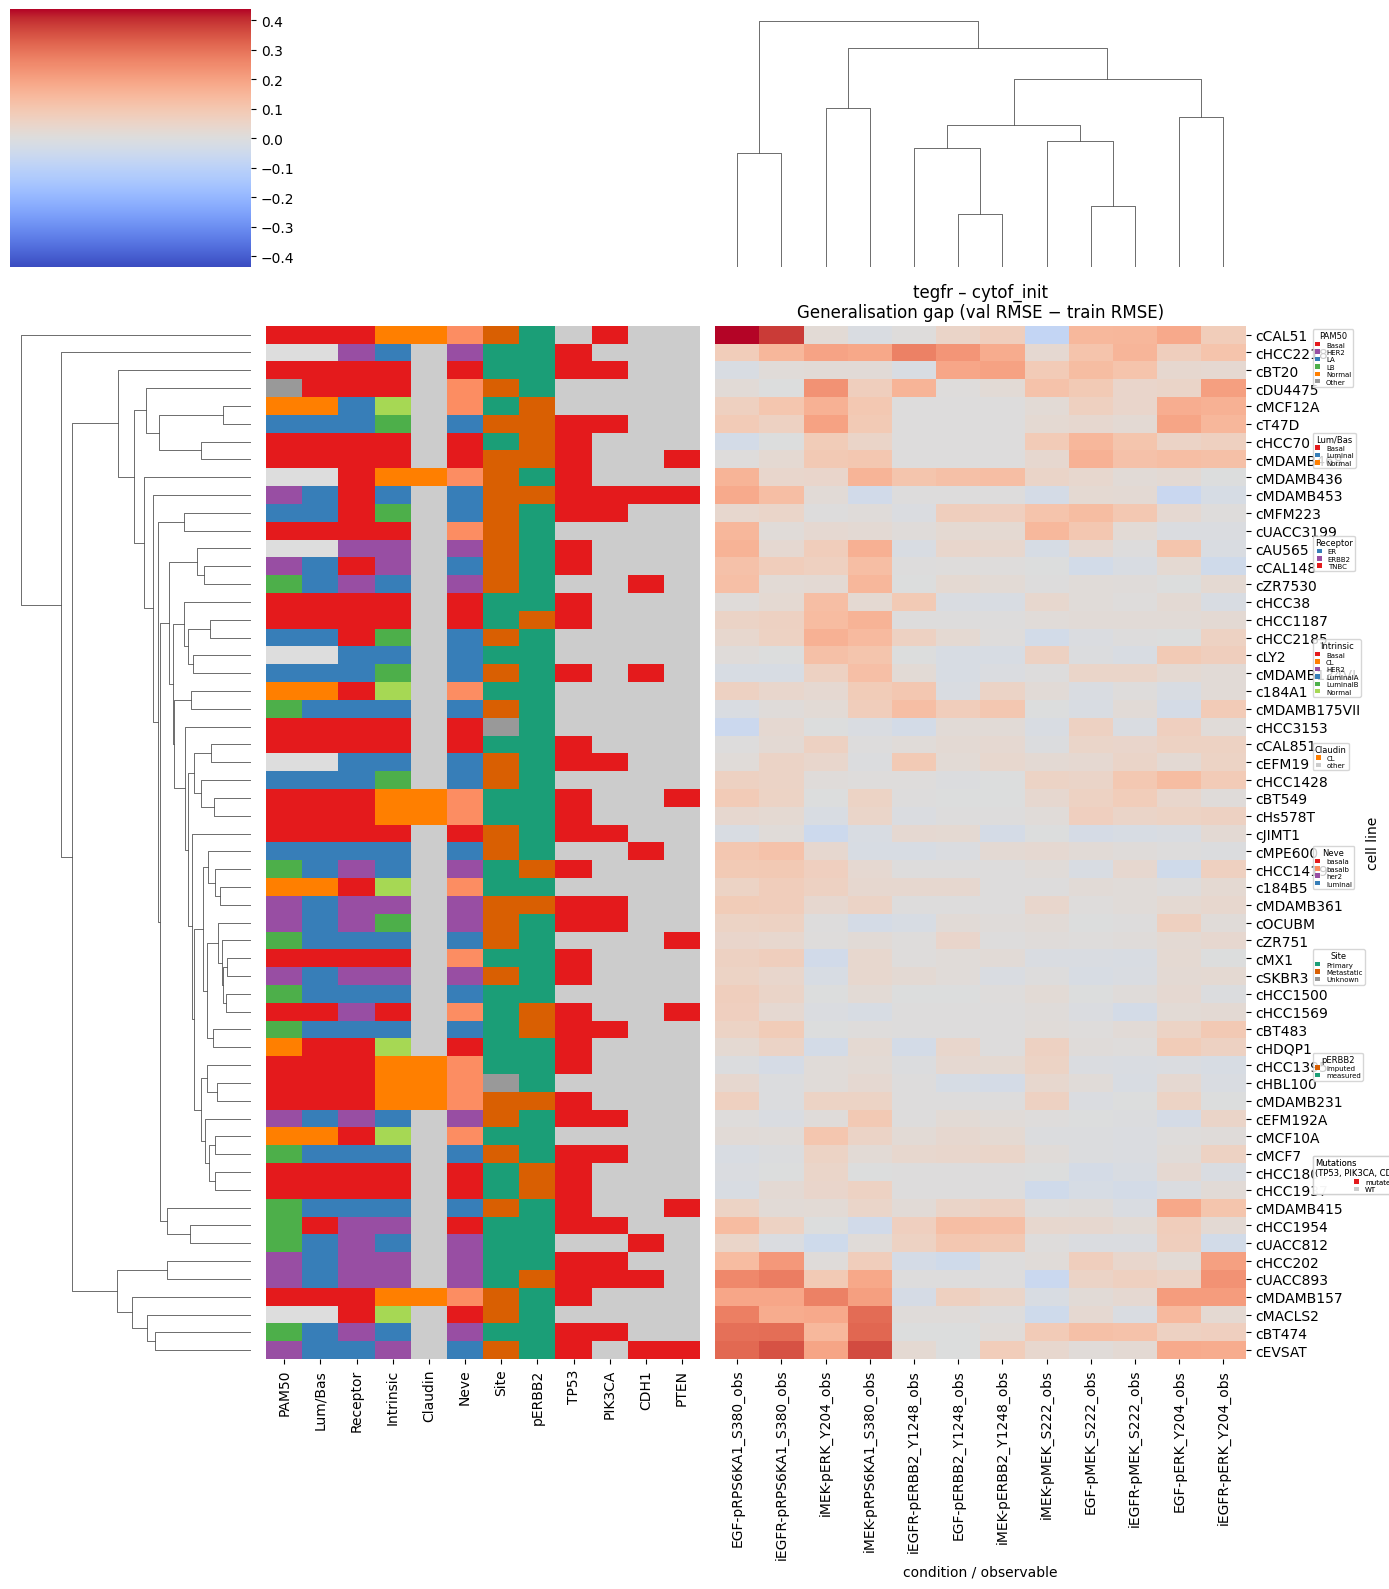

In [66]:
# Gap heatmaps for each model × context combination
# Store ClusterGrid objects so we can extract dendrogram-based outliers later
_gap_clustergrid = {}
for model_label in models:
    for context in sorted(by_dfs[model_label]["context"].dropna().unique()):
        print(f"\n{'='*60}")
        print(f"Model: {model_label}, Context: {context}")
        print(f"{'='*60}")

        cg = plot_heatmap(by_df, model_label, context, ANNOTATION_SPECS, mode="gap")
        _gap_clustergrid[(model_label, context)] = cg
        plt.show()


RMSE heatmap – Model: tegfr, Context: cytof_init


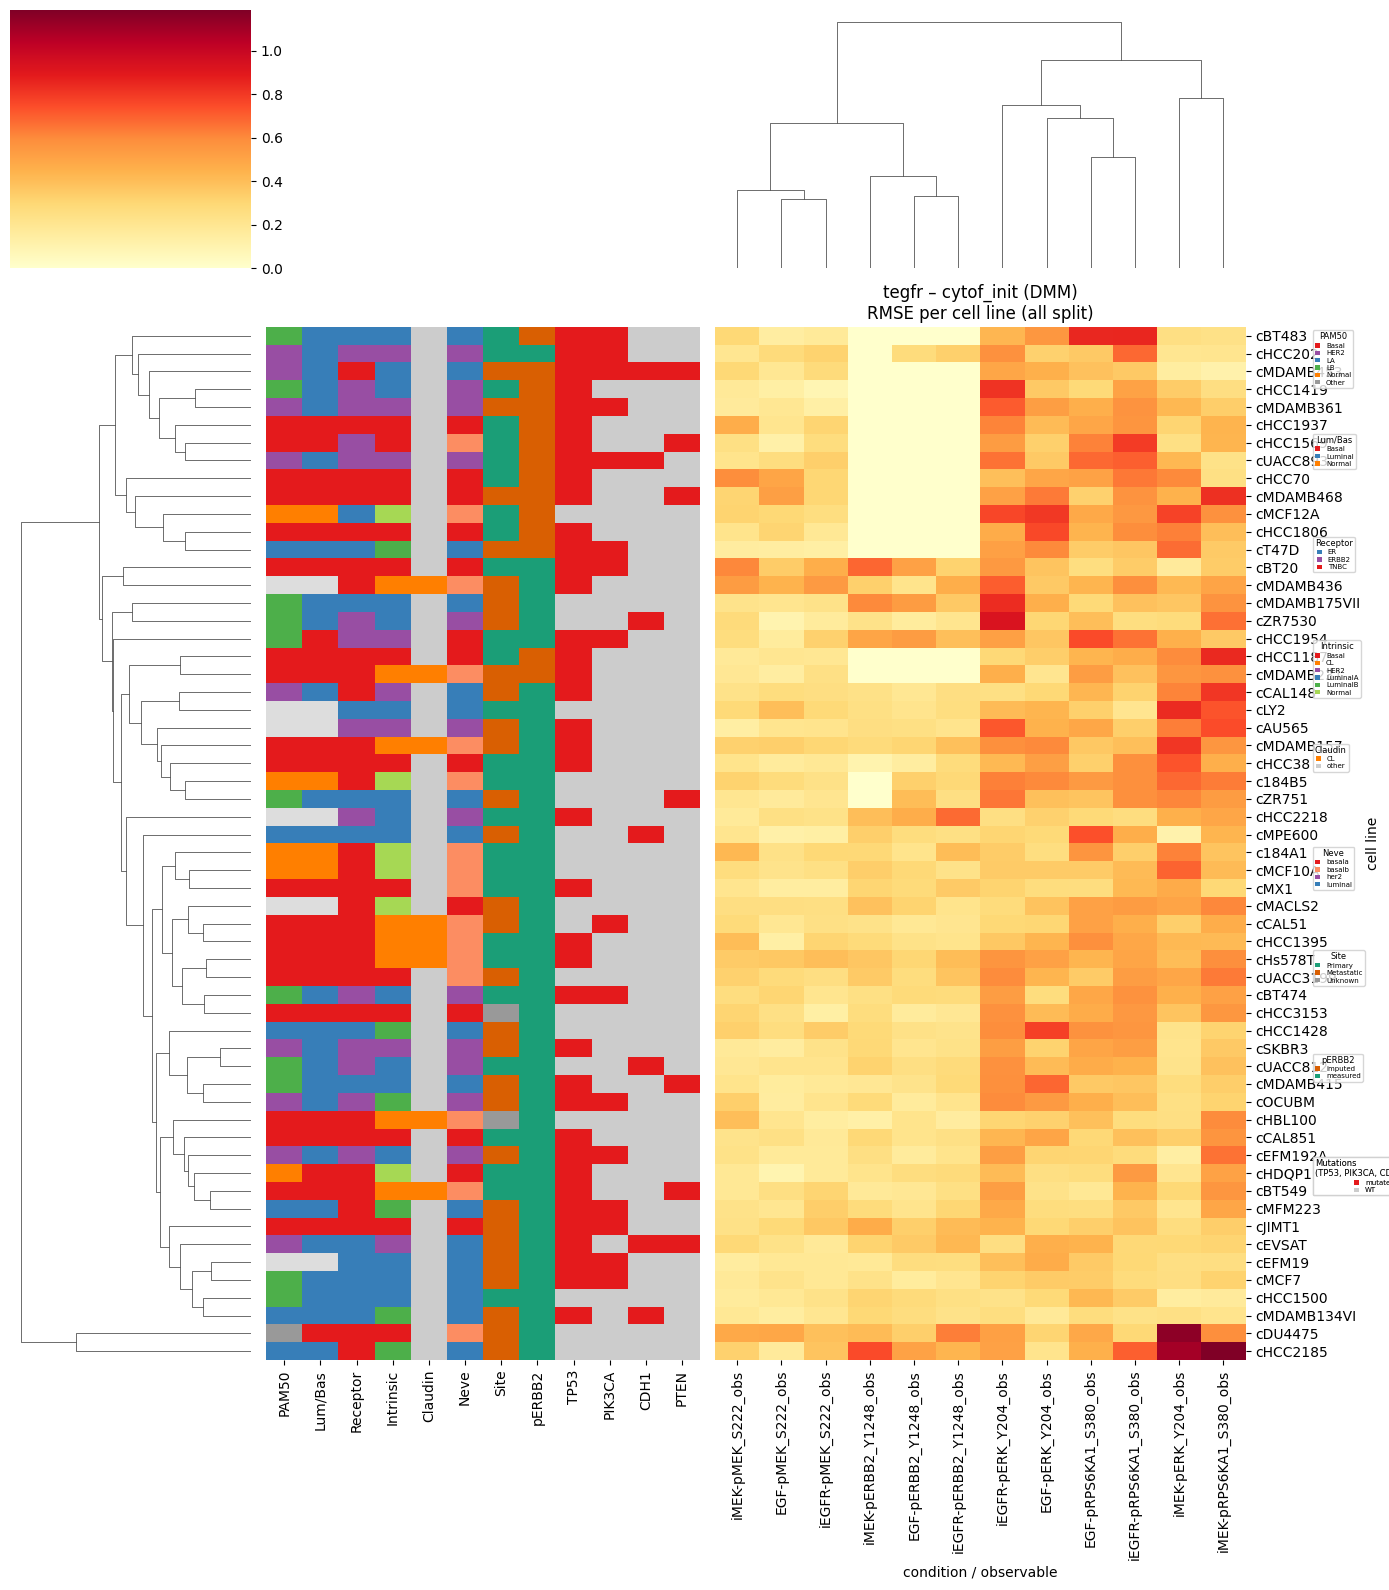

In [67]:
# RMSE heatmaps for each model × context combination
# Store ClusterGrid objects so we can extract dendrogram-based outliers later
_rmse_clustergrid = {}
for model_label in models:
    for context in sorted(by_dfs[model_label]["context"].dropna().unique()):
        print(f"\n{'='*60}")
        print(f"RMSE heatmap – Model: {model_label}, Context: {context}")
        print(f"{'='*60}")

        cg = plot_heatmap(all_df, model_label, context, ANNOTATION_SPECS, mode="rmse")
        _rmse_clustergrid[(model_label, context)] = cg
        plt.show()

CyTOF matrix: 63 cell lines × 137 features
PCA done: 63 cell lines, PC1=50.7%, PC2=10.3% variance explained
Dendrogram outliers (8): ['cBT474', 'cCAL51', 'cEVSAT', 'cHCC202', 'cHCC2218', 'cMACLS2', 'cMDAMB157', 'cUACC893']
Common cell lines: 58
Dendrogram outliers (8): ['cBT474', 'cCAL51', 'cEVSAT', 'cHCC202', 'cHCC2218', 'cMACLS2', 'cMDAMB157', 'cUACC893']
Common cell lines: 58


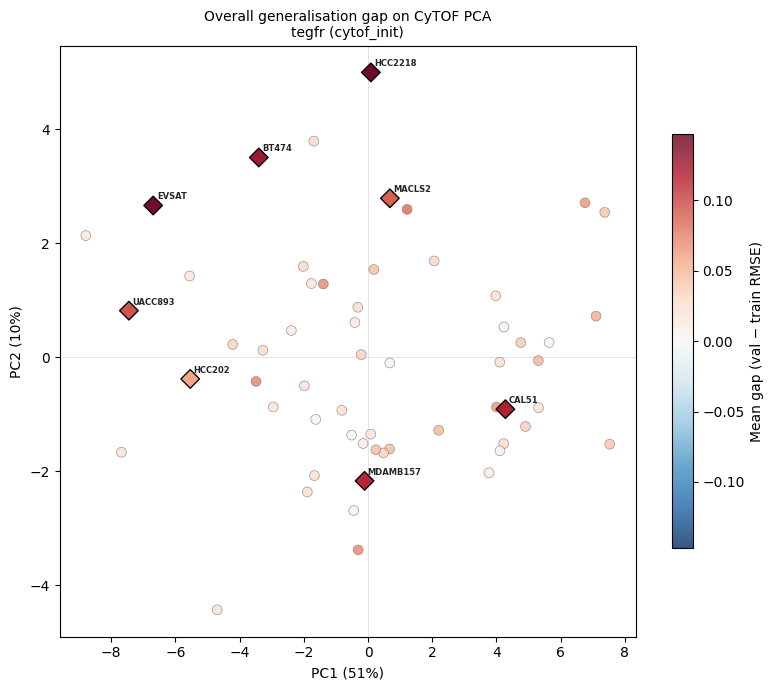

In [68]:
# --- Generalisation gap on PCA embedding of CyTOF baseline data ---------------
# plot_gap_on_pca / plot_gap_on_pca_v2 imported from gap_analysis.

from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer
from dmm.config_options import Conf
from dmm.feature_selection import contextualize_measurements
from cytof import get_samples
from util import load_petab_base_files
from adjustText import adjust_text

# --- Load CyTOF measurement matrix ---
_conf = Conf(model="EGFR_MAPK__logobs", data="dream_cytof")
_files = load_petab_base_files(_conf)
_all_samples = sorted(get_samples(_conf.data))

_cytof_mat, _ = contextualize_measurements(
    measurement_table=_files["measurement_table"],
    observable_table=_files["observable_table"],
    contextualization="cytof_dynamic",
    samples=_all_samples,
    impute=False,
)
print(f"CyTOF matrix: {_cytof_mat.shape[0]} cell lines × {_cytof_mat.shape[1]} features")

# KNN-impute and PCA
_X_imp = KNNImputer().fit_transform(_cytof_mat.values)
_pca = PCA(n_components=10)
_Xt = _pca.fit_transform(_X_imp)
_ve1, _ve2 = _pca.explained_variance_ratio_[:2]

_pca_df = pd.DataFrame(
    {"PC1": _Xt[:, 0], "PC2": _Xt[:, 1]},
    index=_cytof_mat.index,
)
_pca_df.index.name = "cell_line"
print(f"PCA done: {_pca_df.shape[0]} cell lines, "
      f"PC1={_ve1:.1%}, PC2={_ve2:.1%} variance explained")

# --- Build per-(condition, observable) gap for the first model/context ---
_model_label = list(models.keys())[0]
_context = sorted(by_dfs[_model_label]["context"].dropna().unique())[0]

_flags, _summary, _gap_mat = detect_heatmap_outliers(
    by_df, model_label=_model_label, context=_context, mode="gap", ref="DMM")

_overall_gap = _gap_mat.mean(axis=1)
_overall_gap.name = "overall_gap"

# Outliers from hierarchical clustering dendrogram (gap heatmap)
_cg_key = (_model_label, _context)
if _cg_key in _gap_clustergrid:
    _outlier_cls = outliers_from_dendrogram(_gap_clustergrid[_cg_key])
    print(f"Dendrogram outliers ({len(_outlier_cls)}): {sorted(_outlier_cls)}")
else:
    _outlier_cls = set(_summary["cell_line"].values) if not _summary.empty else set()
    print(f"WARNING: no ClusterGrid for {_cg_key}, falling back to IQR outliers")
_common = sorted(set(_pca_df.index) & set(_gap_mat.index))
print(f"Common cell lines: {len(_common)}")

# --- 1. Overall gap on PCA ---
fig, ax = plt.subplots(figsize=(8, 7))
sc = plot_gap_on_pca(_pca_df, _overall_gap, _outlier_cls,
                     f"Overall generalisation gap on CyTOF PCA\n{_model_label} ({_context})",
                     ax, ve1=_ve1, ve2=_ve2)
plt.colorbar(sc, ax=ax, label="Mean gap (val − train RMSE)", shrink=0.7)
fig.tight_layout()
plt.savefig(str(Path(_project_root) / "figures_paper" /
                f"gap_on_pca_overall_{_model_label}_{_context}.pdf"),
            bbox_inches="tight", dpi=150)
plt.show()

In [69]:
# Outlier cell lines from hierarchical clustering (dendrogram)

# --- Load cBioPortal mutation data (needed here, full loading in cell below) ---
import cell_line_annotations as cla
_all_cls = sorted(_gap_mat.index)
_ann = cla.get_all_annotations(_all_cls, cache_dir=features_dir, file_dir=features_dir)
_cbio_df = _ann["cbio_df"]
_covered_cls = set(_cbio_df["cell_line"].unique())

# Build annotation DataFrame with gap per cell line
_annot_gap = _overall_gap.to_frame()

_dendro_outliers = _annot_gap.loc[_annot_gap.index.isin(_outlier_cls)].sort_values(
    "overall_gap", ascending=False)
print(f"Dendrogram outlier cell lines ({len(_dendro_outliers)}):")
for cl, row in _dendro_outliers.iterrows():
    print(f"  {cl}: gap = {row['overall_gap']:.4f}")
print()

# All mutations in these cell lines for the EGFR/MAPK pathway genes
_outlier_mapk = _cbio_df[
    (_cbio_df["cell_line"].isin(_dendro_outliers.index)) &
    (_cbio_df["gene"].isin(_MAPK_GENES))
].sort_values(["cell_line", "gene"])

if _outlier_mapk.empty:
    print("No EGFR/MAPK pathway mutations found in these cell lines.")
else:
    print(f"EGFR/MAPK pathway mutations in dendrogram-outlier cell lines "
          f"({len(_outlier_mapk)} total):\n")
    display(_outlier_mapk[["cell_line", "gene", "mutationType",
                           "proteinChange", "variantType"]]
            .reset_index(drop=True))

# Also show all mutations in these cell lines (broad view) for context
print(f"\n--- All mutations in dendrogram-outlier cell lines (summary) ---")
for cl in _dendro_outliers.index:
    _cl_muts = _cbio_df[_cbio_df["cell_line"] == cl]
    _n_genes = _cl_muts["gene"].nunique()
    _mapk_hits = _cl_muts[_cl_muts["gene"].isin(_MAPK_GENES)]["gene"].unique()
    _mapk_str = ", ".join(sorted(_mapk_hits)) if len(_mapk_hits) > 0 else "none"
    _in_cbio = cl in _covered_cls
    print(f"  {cl} (gap={_dendro_outliers.loc[cl, 'overall_gap']:.4f}): "
          f"{'in cBioPortal' if _in_cbio else '** NOT in cBioPortal **'}, "
          f"{_n_genes} unique mutated genes, "
          f"MAPK hits: {_mapk_str}")

══════════════════════════════════════════════════════════════════════
Fetching all cell-line annotations …
══════════════════════════════════════════════════════════════════════

[1/4] Cellosaurus …
  [cache hit] Cellosaurus annotations loaded from cache

[2/4] cBioPortal CCLE …
  [cache hit] cBioPortal mutations loaded from cache

[3/4] Cell Model Passports …
  [cache hit] 791 CMP driver genes loaded from cache
  [cache hit] CMP driver mutations loaded from cache

[4/4] Subtypes …
  PAM50: 52 cell lines, LB: 52 cell lines

══════════════════════════════════════════════════════════════════════
All annotations fetched.
══════════════════════════════════════════════════════════════════════
Dendrogram outlier cell lines (8):
  cHCC2218: gap = 0.1470
  cEVSAT: gap = 0.1453
  cBT474: gap = 0.1277
  cCAL51: gap = 0.1199
  cMDAMB157: gap = 0.1167
  cUACC893: gap = 0.0964
  cMACLS2: gap = 0.0916
  cHCC202: gap = 0.0594



NameError: name '_MAPK_GENES' is not defined

In [ ]:
# ── Prevalence of MAPK mutations found in dendrogram-outlier cell lines ─
# Automatically extract (gene, proteinChange) pairs from outlier cell lines
_outlier_mapk_mutations = (
    _cbio_df[
        (_cbio_df["cell_line"].isin(_outlier_cls)) &
        (_cbio_df["gene"].isin(_MAPK_GENES))
    ][["gene", "proteinChange"]]
    .dropna(subset=["proteinChange"])
    .drop_duplicates()
    .sort_values(["gene", "proteinChange"])
    .values.tolist()
)
print(f"MAPK mutations in outlier cell lines: {len(_outlier_mapk_mutations)} "
      f"unique (gene, proteinChange) pairs\n")

print("Prevalence of each specific mutation (exact protein change):")
print("-" * 70)
for gene, pchange in _outlier_mapk_mutations:
    _hits = _cbio_df[
        (_cbio_df["gene"] == gene) & (_cbio_df["proteinChange"] == pchange)
    ]["cell_line"].unique()
    _in_outlier = set(_hits) & _outlier_cls
    _in_inlier = set(_hits) - _outlier_cls
    print(f"  {gene} {pchange}: {len(_hits)}/{len(_covered_cls)} cell lines "
          f"(outlier: {', '.join(sorted(_in_outlier)) or 'none'}"
          f"{'; inlier: ' + ', '.join(sorted(_in_inlier)) if _in_inlier else ''})")

print(f"\nPrevalence of any mutation in each gene (regardless of position):")
print("-" * 70)
_seen_genes = set()
for gene, _ in _outlier_mapk_mutations:
    if gene in _seen_genes:
        continue
    _seen_genes.add(gene)
    _hits_any = _cbio_df[_cbio_df["gene"] == gene]["cell_line"].unique()
    _in_outlier_any = set(_hits_any) & _outlier_cls
    print(f"  {gene} (any): {len(_hits_any)}/{len(_covered_cls)} cell lines "
          f"(outlier: {len(_in_outlier_any)}, inlier: {len(_hits_any) - len(_in_outlier_any)})"
          f" → {', '.join(sorted(_hits_any))}")

NameError: name '_cbio_df' is not defined

In [ ]:
# ── All mutations in BRAF, EGFR, MAPK1, RAF1 across our cell lines ────
_focus_genes = ["BRAF", "EGFR", "MAPK1", "RAF1"]
_top4_cls = set(_annot_gap.nlargest(4, "overall_gap").index)

_focus_muts = (_cbio_df[_cbio_df["gene"].isin(_focus_genes)]
               .sort_values(["gene", "cell_line"])
               [["cell_line", "gene", "mutationType", "proteinChange", "variantType"]]
               .reset_index(drop=True))

# Add gap and flag whether the cell line is a dendrogram outlier
_focus_muts["overall_gap"] = _focus_muts["cell_line"].map(
    _annot_gap["overall_gap"]).round(4)
_focus_muts["is_outlier"] = _focus_muts["cell_line"].isin(_outlier_cls)

print(f"All mutations in {_focus_genes} across {len(_covered_cls)} cell lines:\n")
display(_focus_muts.style.apply(
    lambda row: ["background: #ffe0e0"] * len(row) if row["is_outlier"] else [""] * len(row),
    axis=1))

NameError: name '_annot_gap' is not defined

In [ ]:
# ── MAP2K4 mutations across our cell lines ────────────────────────────
_map2k4_muts = (_cbio_df[_cbio_df["gene"] == "MAP2K4"]
                .sort_values("cell_line")
                [["cell_line", "gene", "mutationType", "proteinChange", "variantType"]]
                .reset_index(drop=True))
_map2k4_muts["overall_gap"] = _map2k4_muts["cell_line"].map(
    _annot_gap["overall_gap"]).round(4)

_map2k4_muts["is_outlier"] = _map2k4_muts["cell_line"].isin(_outlier_cls)

print(f"MAP2K4 mutations: {len(_map2k4_muts)} in "
      f"{_map2k4_muts['cell_line'].nunique()}/{len(_covered_cls)} cell lines\n")
print(_map2k4_muts.to_string(index=False))

# Also check MAP2K1, MAP2K2 (MEK1/2) for completeness
for _g in ["MAP2K1", "MAP2K2", "MAP2K4", "MAP2K7",
           "MAP3K1", "MAP3K7"]:
    _g_muts = _cbio_df[_cbio_df["gene"] == _g]
    if not _g_muts.empty:
        _cls = sorted(_g_muts["cell_line"].unique())
        _gaps = [f"{cl}({_annot_gap.loc[cl,'overall_gap']:.3f})" for cl in _cls]
        print(f"\n{_g}: {len(_cls)} cell lines → {', '.join(_gaps)}")

MAP2K4 mutations: 4 in 4/46 cell lines

  cell_line   gene      mutationType proteinChange variantType  overall_gap  is_outlier
     cCAL51 MAP2K4 Missense_Mutation         G265D         SNP       0.1196        True
   cHCC1569 MAP2K4 Missense_Mutation         P338L         SNP       0.0067       False
cMDAMB134VI MAP2K4 Missense_Mutation         S184L         SNP       0.0237       False
  cMDAMB415 MAP2K4 Nonsense_Mutation         S280*         SNP       0.0465       False

MAP2K1: 1 cell lines → cCAL148(0.029)

MAP2K2: 1 cell lines → cMDAMB361(0.029)

MAP2K4: 4 cell lines → cCAL51(0.120), cHCC1569(0.007), cMDAMB134VI(0.024), cMDAMB415(0.046)

MAP3K1: 1 cell lines → cMDAMB415(0.046)

MAP3K7: 2 cell lines → cCAL851(0.030), cMDAMB453(0.019)

MAP3K1: 1 cell lines → cMDAMB415(0.046)

MAP3K7: 2 cell lines → cCAL851(0.030), cMDAMB453(0.019)


In [ ]:
# ── MAPK mutation enrichment in dendrogram-outlier cell lines ─────────
# Use focused, canonical MSigDB C2:CP gene sets to define MAPK/ERK pathway
# genes, then test whether dendrogram outliers carry more MAPK mutations than inliers.
# Also analyse overall mutational burden (all genes), doubling time, and correlate with gap.

from scipy.stats import fisher_exact, mannwhitneyu, spearmanr
from gene_shells import load_msigdb_gmt
from statsmodels.stats.multitest import multipletests

# --- 1. Get outlier cell lines (dendrogram-based from gap heatmap) ---
_model_label = list(models.keys())[0]
_context = sorted(by_dfs[_model_label]["context"].dropna().unique())[0]

_flags_ol, _summary_ol, _mat_ol = detect_heatmap_outliers(
    by_df, model_label=_model_label, context=_context, mode="gap", ref="DMM")

# Use dendrogram clustering instead of IQR
_cg_key = (_model_label, _context)
if _cg_key in _gap_clustergrid:
    _outlier_cls = outliers_from_dendrogram(_gap_clustergrid[_cg_key])
else:
    _outlier_cls = set(_summary_ol["cell_line"].values)
_all_heatmap_cls = set(_mat_ol.index)
_inlier_cls = _all_heatmap_cls - _outlier_cls

# Restrict to cell lines present in cBioPortal
_outlier_in_cbio = _outlier_cls & _covered_cls
_inlier_in_cbio = _inlier_cls & _covered_cls
_test_cls = sorted(_outlier_in_cbio | _inlier_in_cbio)
print(f"\nOutlier cell lines: {len(_outlier_cls)} total, {len(_outlier_in_cbio)} in cBioPortal")
print(f"Inlier cell lines:  {len(_inlier_cls)} total, {len(_inlier_in_cbio)} in cBioPortal")

# --- 2. Binary enrichment: any MAPK mutation (union) ---
_mapk_cls = set(_cbio_df[_cbio_df["gene"].isin(_MAPK_GENES)]["cell_line"].unique())
_out_mut = len(_outlier_in_cbio & _mapk_cls)
_out_wt  = len(_outlier_in_cbio) - _out_mut
_in_mut  = len(_inlier_in_cbio & _mapk_cls)
_in_wt   = len(_inlier_in_cbio) - _in_mut
_ct_bin  = np.array([[_out_mut, _out_wt], [_in_mut, _in_wt]])
_or_bin, _p_bin = fisher_exact(_ct_bin)
frac_outlier_msigdb = _out_mut / (_out_mut + _out_wt)
frac_inlier_msigdb  = _in_mut / (_in_mut + _in_wt)

print(f"\n{'='*70}")
print(f"BINARY ENRICHMENT – any MAPK mutation (union, {len(_MAPK_GENES)} genes)")
print(f"{'='*70}")
print(f"Outlier: {_out_mut}/{_out_mut+_out_wt} = {frac_outlier_msigdb:.0%} mutated")
print(f"Inlier:  {_in_mut}/{_in_mut+_in_wt} = {frac_inlier_msigdb:.0%} mutated")
print(f"Fisher exact: OR={_or_bin:.2f}, p={_p_bin:.4f}")

# --- 3. MAPK & overall mutation BURDEN ---
_mapk_muts_per_cl = (_cbio_df[_cbio_df["gene"].isin(_MAPK_GENES)]
                     .groupby("cell_line")["gene"].nunique()
                     .rename("n_mapk_muts"))
_all_muts_per_cl = (_cbio_df.groupby("cell_line")["gene"].nunique()
                    .rename("n_total_muts"))

_analysis = pd.DataFrame({"cell_line": _test_cls})
_analysis["is_outlier"] = _analysis["cell_line"].isin(_outlier_in_cbio)
_analysis["n_mapk_muts"] = _analysis["cell_line"].map(_mapk_muts_per_cl).fillna(0).astype(int)
_analysis["n_total_muts"] = _analysis["cell_line"].map(_all_muts_per_cl).fillna(0).astype(int)
_analysis["n_outlier_cols"] = _analysis["cell_line"].map(
    _summary_ol.set_index("cell_line")["n_outlier_cols"]).fillna(0).astype(int)
_analysis["overall_gap"] = _analysis["cell_line"].map(_overall_gap)

# -- MAPK burden: outlier vs inlier --
_out_burden = _analysis[_analysis["is_outlier"]]["n_mapk_muts"]
_in_burden = _analysis[~_analysis["is_outlier"]]["n_mapk_muts"]
_u_burden, _p_burden = mannwhitneyu(_out_burden, _in_burden, alternative="greater")

# -- Overall burden: outlier vs inlier --
_out_total = _analysis[_analysis["is_outlier"]]["n_total_muts"]
_in_total = _analysis[~_analysis["is_outlier"]]["n_total_muts"]
_u_total, _p_total = mannwhitneyu(_out_total, _in_total, alternative="greater")

print(f"\n{'='*70}")
print("MUTATION BURDEN – outlier vs inlier")
print(f"{'='*70}")
print(f"MAPK ({len(_MAPK_GENES)} genes):")
print(f"  Outliers: median={_out_burden.median():.0f}, mean={_out_burden.mean():.1f} "
      f"(n={len(_out_burden)})")
print(f"  Inliers:  median={_in_burden.median():.0f}, mean={_in_burden.mean():.1f} "
      f"(n={len(_in_burden)})")
print(f"  Mann-Whitney (outlier > inlier): U={_u_burden:.0f}, p={_p_burden:.4f}")
print(f"\nOverall (all genes):")
print(f"  Outliers: median={_out_total.median():.0f}, mean={_out_total.mean():.1f} "
      f"(n={len(_out_total)})")
print(f"  Inliers:  median={_in_total.median():.0f}, mean={_in_total.mean():.1f} "
      f"(n={len(_in_total)})")
print(f"  Mann-Whitney (outlier > inlier): U={_u_total:.0f}, p={_p_total:.4f}")

# --- 3b. Doubling time: outlier vs inlier ---
_dt_col = "Doubling_Time_Hours"
_analysis["doubling_time"] = _analysis["cell_line"].map(
    cello_annot[_dt_col] if _dt_col in cello_annot.columns
    else pd.Series(dtype=float))

_dt_valid = _analysis.dropna(subset=["doubling_time"])
_dt_coverage = len(_dt_valid)
_out_dt = _dt_valid[_dt_valid["is_outlier"]]["doubling_time"]
_in_dt  = _dt_valid[~_dt_valid["is_outlier"]]["doubling_time"]

if len(_out_dt) >= 2 and len(_in_dt) >= 2:
    _u_dt, _p_dt = mannwhitneyu(_out_dt, _in_dt, alternative="two-sided")
    _rho_dt_gap, _p_dt_gap = spearmanr(
        _dt_valid["overall_gap"], _dt_valid["doubling_time"])
else:
    _u_dt, _p_dt = np.nan, np.nan
    _rho_dt_gap, _p_dt_gap = np.nan, np.nan

print(f"\n{'='*70}")
print("DOUBLING TIME – outlier vs inlier  (source: Cellosaurus)")
print(f"{'='*70}")
print(f"  Coverage: {_dt_coverage}/{len(_analysis)} cell lines "
      f"({len(_out_dt)} outliers, {len(_in_dt)} inliers with data)")
print(f"  Outliers: median={_out_dt.median():.1f}h, mean={_out_dt.mean():.1f}h")
print(f"  Inliers:  median={_in_dt.median():.1f}h, mean={_in_dt.mean():.1f}h")
print(f"  Mann-Whitney (two-sided): U={_u_dt:.0f}, p={_p_dt:.4f}")
print(f"  Spearman (gap vs doubling time): ρ={_rho_dt_gap:+.3f}, p={_p_dt_gap:.4f}")

# -- Spearman correlations with generalisation gap --
_rho_mapk_gap, _p_mapk_gap = spearmanr(_analysis["overall_gap"], _analysis["n_mapk_muts"])
_rho_total_gap, _p_total_gap = spearmanr(_analysis["overall_gap"], _analysis["n_total_muts"])
_rho_mapk_sev, _p_mapk_sev = spearmanr(_analysis["n_outlier_cols"], _analysis["n_mapk_muts"])
_rho_total_sev, _p_total_sev = spearmanr(_analysis["n_outlier_cols"], _analysis["n_total_muts"])

print(f"\n{'='*70}")
print("CORRELATION: mutation burden vs generalisation gap / outlier severity")
print(f"{'='*70}")
print(f"{'Burden type':<20s} {'vs gap (ρ, p)':<25s} {'vs # outlier cols (ρ, p)':<25s}")
print(f"{'-'*70}")
print(f"{'MAPK':<20s} ρ={_rho_mapk_gap:+.3f}, p={_p_mapk_gap:.4f}   "
      f"ρ={_rho_mapk_sev:+.3f}, p={_p_mapk_sev:.4f}")
print(f"{'Overall':<20s} ρ={_rho_total_gap:+.3f}, p={_p_total_gap:.4f}   "
      f"ρ={_rho_total_sev:+.3f}, p={_p_total_sev:.4f}")
print(f"{'Doubling time':<20s} ρ={_rho_dt_gap:+.3f}, p={_p_dt_gap:.4f}")

# --- 4. Per-geneset enrichment (Fisher: outlier vs inlier) ---
print(f"\n{'='*70}")
print("PER-GENESET ENRICHMENT (outlier vs inlier, Fisher exact)")
print(f"{'='*70}")

_gs_results = []
for gs_name, gs_label in _matched_sets.items():
    gs_genes = set(_gmt[gs_name])
    _mutated_in_gs = set(_cbio_df[_cbio_df["gene"].isin(gs_genes)]["cell_line"].unique())
    _df = pd.DataFrame({
        "is_outlier": [cl in _outlier_in_cbio for cl in _test_cls],
        "has_mut": [cl in _mutated_in_gs for cl in _test_cls],
    }, index=_test_cls)
    ct = pd.crosstab(_df["is_outlier"], _df["has_mut"])
    if ct.shape == (2, 2) and True in ct.columns:
        odds_gs, p_gs = fisher_exact(ct)
        n_out = ct.loc[True, True]
        n_in = ct.loc[False, True]
    else:
        odds_gs, p_gs = np.nan, 1.0
        n_out = ct.loc[True, True] if (True in ct.index and True in ct.columns) else 0
        n_in = ct.loc[False, True] if (False in ct.index and True in ct.columns) else 0
    _gs_results.append({
        "gene_set": gs_name, "label": gs_label, "n_genes": len(gs_genes),
        "n_outlier_mut": n_out, "n_inlier_mut": n_in,
        "outlier_frac": n_out / len(_outlier_in_cbio) if len(_outlier_in_cbio) else 0,
        "inlier_frac": n_in / len(_inlier_in_cbio) if len(_inlier_in_cbio) else 0,
        "odds_ratio": odds_gs, "p_value": p_gs,
    })

_gs_table = pd.DataFrame(_gs_results).sort_values("p_value")
if not _gs_table.empty:
    _gs_table["q_value"] = multipletests(_gs_table["p_value"], method="fdr_bh")[1]
    for _, row in _gs_table.iterrows():
        sig = ("***" if row["q_value"] < 0.001 else "**" if row["q_value"] < 0.01
               else "*" if row["q_value"] < 0.05 else "†" if row["p_value"] < 0.05 else "")
        print(f"  {row['label']:30s} ({row['n_genes']:>3.0f}g): "
              f"OR={row['odds_ratio']:.2f}, p={row['p_value']:.3g}, q={row['q_value']:.3g} {sig}  "
              f"(out={row['outlier_frac']:.0%}, in={row['inlier_frac']:.0%})")
    print()
    display(_gs_table[["label", "gene_set", "n_genes", "n_outlier_mut", "n_inlier_mut",
                        "outlier_frac", "inlier_frac", "odds_ratio", "p_value", "q_value"]].round(3))

# --- 5. Per-gene breakdown (top MAPK genes mutated in ≥2 cell lines) ---
print(f"\n{'='*70}")
print("PER-GENE MAPK ENRICHMENT (outlier vs inlier)")
print(f"{'='*70}")

_mapk_gene_counts = (_cbio_df[_cbio_df["gene"].isin(_MAPK_GENES)]
                     .groupby("gene")["cell_line"].nunique()
                     .sort_values(ascending=False))
_testable_genes = _mapk_gene_counts[_mapk_gene_counts >= 2].index.tolist()
print(f"Testing {len(_testable_genes)} MAPK genes mutated in ≥2 cell lines")

_gene_results_ol = []
for gene in _testable_genes:
    _gene_cls = set(_cbio_df[_cbio_df["gene"] == gene]["cell_line"].unique())
    _test_df_g = pd.DataFrame({
        "is_outlier": [cl in _outlier_in_cbio for cl in _test_cls],
        "has_mut": [cl in _gene_cls for cl in _test_cls],
    }, index=_test_cls)
    ct_g = pd.crosstab(_test_df_g["is_outlier"], _test_df_g["has_mut"])
    if ct_g.shape == (2, 2) and True in ct_g.columns:
        odds_g, p_g = fisher_exact(ct_g)
        n_out = ct_g.loc[True, True] if True in ct_g.index else 0
        n_in = ct_g.loc[False, True] if False in ct_g.index else 0
        _gene_results_ol.append({
            "gene": gene, "n_mutated_total": len(_gene_cls),
            "n_outlier_mut": n_out, "n_inlier_mut": n_in,
            "outlier_frac": n_out / ct_g.loc[True].sum() if True in ct_g.index else 0,
            "inlier_frac": n_in / ct_g.loc[False].sum() if False in ct_g.index else 0,
            "odds_ratio": odds_g, "p_value": p_g,
        })

_gene_ol_df = pd.DataFrame(_gene_results_ol).sort_values("p_value")
if not _gene_ol_df.empty:
    _gene_ol_df["q_value"] = multipletests(_gene_ol_df["p_value"], method="fdr_bh")[1]
    for _, row in _gene_ol_df.head(15).iterrows():
        sig = ("***" if row["q_value"] < 0.001 else "**" if row["q_value"] < 0.01
               else "*" if row["q_value"] < 0.05 else "†" if row["p_value"] < 0.05 else "")
        print(f"  {row['gene']:12s} (n={row['n_mutated_total']:2.0f}): "
              f"out={row['outlier_frac']:.0%} vs in={row['inlier_frac']:.0%} | "
              f"OR={row['odds_ratio']:.2f}, p={row['p_value']:.3g}, q={row['q_value']:.3g} {sig}")
    print()
    display(_gene_ol_df.head(15).round(3))

# --- 6. Visualisation (3×3 grid) ---
fig, axes = plt.subplots(3, 3, figsize=(17, 15))

_analysis["Group"] = _analysis["is_outlier"].map({True: "Outlier", False: "Inlier"})

# 6a. Boxplot: MAPK mutation burden
ax = axes[0, 0]
sns.boxplot(data=_analysis, x="Group", y="n_mapk_muts",
            order=["Outlier", "Inlier"],
            palette={"Outlier": "#e41a1c", "Inlier": "#cccccc"},
            ax=ax, showfliers=False)
sns.stripplot(data=_analysis, x="Group", y="n_mapk_muts",
              order=["Outlier", "Inlier"],
              color="black", size=4, alpha=0.5, ax=ax, jitter=True)
ax.set_ylabel(f"# mutated MAPK genes\n({len(_MAPK_GENES)} gene union)")
ax.set_xlabel("")
ax.set_title(f"MAPK burden\nMW p = {_p_burden:.3g}")

# 6b. Scatter: generalisation gap vs MAPK burden
ax = axes[0, 1]
ax.scatter(_analysis["n_mapk_muts"], _analysis["overall_gap"],
           s=40, alpha=0.7, edgecolor="grey", linewidth=0.4,
           c=_analysis["is_outlier"].map({True: "#e41a1c", False: "#999999"}))
z = np.polyfit(_analysis["n_mapk_muts"], _analysis["overall_gap"], 1)
xl = np.linspace(_analysis["n_mapk_muts"].min(), _analysis["n_mapk_muts"].max(), 50)
ax.plot(xl, np.polyval(z, xl), color="firebrick", linewidth=1.5, alpha=0.7)
ax.set_xlabel("# mutated MAPK genes")
ax.set_ylabel("Generalisation gap")
ax.set_title(f"Gap vs MAPK burden\nSpearman ρ={_rho_mapk_gap:.2f}, p={_p_mapk_gap:.3g}")

# 6c. Per-geneset enrichment forest plot
ax = axes[0, 2]
if not _gs_table.empty:
    _gs_plot = _gs_table.sort_values("odds_ratio", ascending=True).copy()
    y = np.arange(len(_gs_plot))
    colors = ["#e41a1c" if p < 0.05 else "#999999" for p in _gs_plot["p_value"]]
    log2or = np.log2(_gs_plot["odds_ratio"].clip(lower=0.1).replace([np.inf], 4))
    ax.barh(y, log2or, color=colors, alpha=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels(_gs_plot["label"], fontsize=8)
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.set_xlabel("log₂(OR)")
    ax.set_title("Per-geneset enrichment\n(outlier vs inlier)")
    for i, (_, row) in enumerate(_gs_plot.iterrows()):
        if row["p_value"] < 0.05:
            ax.text(ax.get_xlim()[1] * 0.95, i, "†", fontsize=10,
                    color="#e41a1c", ha="right", va="center")

# 6d. Boxplot: overall mutation burden
ax = axes[1, 0]
sns.boxplot(data=_analysis, x="Group", y="n_total_muts",
            order=["Outlier", "Inlier"],
            palette={"Outlier": "#e41a1c", "Inlier": "#cccccc"},
            ax=ax, showfliers=False)
sns.stripplot(data=_analysis, x="Group", y="n_total_muts",
              order=["Outlier", "Inlier"],
              color="black", size=4, alpha=0.5, ax=ax, jitter=True)
ax.set_ylabel("# mutated genes (all)")
ax.set_xlabel("")
ax.set_title(f"Overall mutation burden\nMW p = {_p_total:.3g}")

# 6e. Scatter: generalisation gap vs overall burden
ax = axes[1, 1]
ax.scatter(_analysis["n_total_muts"], _analysis["overall_gap"],
           s=40, alpha=0.7, edgecolor="grey", linewidth=0.4,
           c=_analysis["is_outlier"].map({True: "#e41a1c", False: "#999999"}))
z = np.polyfit(_analysis["n_total_muts"], _analysis["overall_gap"], 1)
xl = np.linspace(_analysis["n_total_muts"].min(), _analysis["n_total_muts"].max(), 50)
ax.plot(xl, np.polyval(z, xl), color="firebrick", linewidth=1.5, alpha=0.7)
ax.set_xlabel("# mutated genes (all)")
ax.set_ylabel("Generalisation gap")
ax.set_title(f"Gap vs overall burden\nSpearman ρ={_rho_total_gap:.2f}, p={_p_total_gap:.3g}")

# 6f. Scatter: MAPK vs overall burden (check specificity)
ax = axes[1, 2]
ax.scatter(_analysis["n_total_muts"], _analysis["n_mapk_muts"],
           s=40, alpha=0.7, edgecolor="grey", linewidth=0.4,
           c=_analysis["is_outlier"].map({True: "#e41a1c", False: "#999999"}))
_rho_mapk_total, _p_mapk_total = spearmanr(_analysis["n_total_muts"], _analysis["n_mapk_muts"])
ax.set_xlabel("# mutated genes (all)")
ax.set_ylabel("# mutated MAPK genes")
ax.set_title(f"MAPK vs overall burden\nSpearman ρ={_rho_mapk_total:.2f}, p={_p_mapk_total:.3g}")

# 6g. Boxplot: doubling time
ax = axes[2, 0]
_dt_plot = _dt_valid.copy()
_dt_plot["Group"] = _dt_plot["is_outlier"].map({True: "Outlier", False: "Inlier"})
sns.boxplot(data=_dt_plot, x="Group", y="doubling_time",
            order=["Outlier", "Inlier"],
            palette={"Outlier": "#e41a1c", "Inlier": "#cccccc"},
            ax=ax, showfliers=False)
sns.stripplot(data=_dt_plot, x="Group", y="doubling_time",
              order=["Outlier", "Inlier"],
              color="black", size=4, alpha=0.5, ax=ax, jitter=True)
ax.set_ylabel("Doubling time (hours)")
ax.set_xlabel("")
_dt_pstr = f"p = {_p_dt:.3g}" if not np.isnan(_p_dt) else "n/a"
ax.set_title(f"Doubling time\nMW {_dt_pstr}")

# 6h. Scatter: generalisation gap vs doubling time
ax = axes[2, 1]
ax.scatter(_dt_valid["doubling_time"], _dt_valid["overall_gap"],
           s=40, alpha=0.7, edgecolor="grey", linewidth=0.4,
           c=_dt_valid["is_outlier"].map({True: "#e41a1c", False: "#999999"}))
if len(_dt_valid) >= 3:
    z = np.polyfit(_dt_valid["doubling_time"], _dt_valid["overall_gap"], 1)
    xl = np.linspace(_dt_valid["doubling_time"].min(), _dt_valid["doubling_time"].max(), 50)
    ax.plot(xl, np.polyval(z, xl), color="firebrick", linewidth=1.5, alpha=0.7)
ax.set_xlabel("Doubling time (hours)")
ax.set_ylabel("Generalisation gap")
_dt_corr_str = (f"ρ={_rho_dt_gap:.2f}, p={_p_dt_gap:.3g}"
                if not np.isnan(_rho_dt_gap) else "n/a")
ax.set_title(f"Gap vs doubling time\nSpearman {_dt_corr_str}")

# 6i. Scatter: doubling time vs overall mutation burden
ax = axes[2, 2]
_dt_mut = _dt_valid.dropna(subset=["n_total_muts"])
ax.scatter(_dt_mut["n_total_muts"], _dt_mut["doubling_time"],
           s=40, alpha=0.7, edgecolor="grey", linewidth=0.4,
           c=_dt_mut["is_outlier"].map({True: "#e41a1c", False: "#999999"}))
if len(_dt_mut) >= 3:
    _rho_dt_mut, _p_dt_mut = spearmanr(_dt_mut["n_total_muts"], _dt_mut["doubling_time"])
    z = np.polyfit(_dt_mut["n_total_muts"], _dt_mut["doubling_time"], 1)
    xl = np.linspace(_dt_mut["n_total_muts"].min(), _dt_mut["n_total_muts"].max(), 50)
    ax.plot(xl, np.polyval(z, xl), color="firebrick", linewidth=1.5, alpha=0.7)
else:
    _rho_dt_mut, _p_dt_mut = np.nan, np.nan
ax.set_xlabel("# mutated genes (all)")
ax.set_ylabel("Doubling time (hours)")
ax.set_title(f"Doubling time vs mutation burden\nSpearman ρ={_rho_dt_mut:.2f}, p={_p_dt_mut:.3g}")

fig.suptitle(f"Mutation burden, doubling time & generalisation gap – {_model_label} ({_context})",
             fontsize=13, y=1.02)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(str(Path(_project_root) / "figures_paper" /
                f"mutation_burden_gap_{_model_label}_{_context}.pdf"),
            bbox_inches="tight", dpi=150)
plt.show()

# --- 7. Outlier cell line mutation burden summary ---
print(f"\n{'='*70}")
print("OUTLIER CELL LINES – mutation burden ranking")
print(f"{'='*70}")
_outlier_summary = (_analysis[_analysis["is_outlier"]]
                    .sort_values("overall_gap", ascending=False)
                    [["cell_line", "n_mapk_muts", "n_total_muts", "doubling_time",
                      "overall_gap"]]
                    .round(4))
display(_outlier_summary.reset_index(drop=True))


Outlier cell lines: 8 total, 7 in cBioPortal
Inlier cell lines:  50 total, 39 in cBioPortal


NameError: name '_MAPK_GENES' is not defined

Outlier-exclusive MAPK genes (p < 0.05, 0 inlier mutations): ['RAC1', 'TGFBR2', 'MAPK10']
Near-exclusive (p < 0.10, ≤1 inlier): ['CDC25B', 'RAF1', 'SPRED2', 'MAP3K11']

VARIANT DETAILS – outlier-exclusive / near-exclusive MAPK genes


,gene,cell_line,is_outlier,mutationType,proteinChange,keyword,variantType,overall_gap
0,CDC25B,cBT474,True,Missense_Mutation,E216K,CDC25B E216 missense,SNP,0.127679
1,CDC25B,cMDAMB157,True,Missense_Mutation,I132V,CDC25B I132 missense,SNP,0.116686
2,CDC25B,cHs578T,False,Missense_Mutation,D343N,CDC25B D343 missense,SNP,0.028119
3,MAP3K11,cBT474,True,Missense_Mutation,E536Q,MAP3K11 E536 missense,SNP,0.127679
4,MAP3K11,cHCC202,True,Missense_Mutation,D595E,MAP3K11 D595 missense,SNP,0.059397
5,MAP3K11,cOCUBM,False,Missense_Mutation,E670D,MAP3K11 E670 missense,SNP,0.015834
6,MAPK10,cBT474,True,Missense_Mutation,R88K,MAPK10 R88 missense,SNP,0.127679
7,MAPK10,cCAL51,True,Splice_Region,X417_splice,None,SNP,0.119880
8,RAC1,cCAL51,True,Missense_Mutation,N39S,RAC1 N39 missense,SNP,0.119880
9,RAC1,cMDAMB157,True,Missense_Mutation,P29S,RAC1 P29 missense,SNP,0.116686



PATHWAY MEMBERSHIP of focus genes
  RAC1         → Biocarta – MAPK, KEGG – MAPK signaling
  TGFBR2       → KEGG – MAPK signaling
  MAPK10       → Biocarta – MAPK, WP – MAPK cascade, KEGG – MAPK signaling
  CDC25B       → KEGG – MAPK signaling
  RAF1         → Biocarta – MAPK, Biocarta – ERK, WP – MAPK cascade, KEGG – MAPK signaling, Reactome – Oncogenic MAPK
  SPRED2       → Reactome – Oncogenic MAPK
  MAP3K11      → Biocarta – MAPK, KEGG – MAPK signaling, Reactome – Oncogenic MAPK

CO-OCCURRENCE – focus genes × outlier cell lines


,cBT474,cCAL51,cEVSAT,cHCC202,cHCC2218,cMDAMB157,cUACC893
RAC1,0.000000,1.00000,0.000000,0.000000,0.000000,1.000000,0.000000
TGFBR2,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000
MAPK10,1.000000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
CDC25B,1.000000,0.00000,0.000000,0.000000,0.000000,1.000000,0.000000
RAF1,0.000000,1.00000,0.000000,1.000000,0.000000,0.000000,0.000000
SPRED2,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000
MAP3K11,1.000000,0.00000,0.000000,1.000000,0.000000,0.000000,0.000000
overall_gap,0.127679,0.11988,0.145341,0.059397,0.146975,0.116686,0.096371



Focus genes per outlier cell line:
  cBT474                5 genes  (gap=0.1277)  ['TGFBR2', 'MAPK10', 'CDC25B', 'SPRED2', 'MAP3K11']
  cCAL51                3 genes  (gap=0.1199)  ['RAC1', 'MAPK10', 'RAF1']
  cEVSAT                0 genes  (gap=0.1453)  []
  cHCC202               2 genes  (gap=0.0594)  ['RAF1', 'MAP3K11']
  cHCC2218              0 genes  (gap=0.1470)  []
  cMDAMB157             2 genes  (gap=0.1167)  ['RAC1', 'CDC25B']
  cUACC893              2 genes  (gap=0.0964)  ['TGFBR2', 'SPRED2']

GAP: carriers of any focus gene vs non-carriers
  Carriers:     n=9, median gap=0.0594, mean=0.0692
  Non-carriers: n=37, median gap=0.0296, mean=0.0390
  Mann-Whitney (carrier > non-carrier): U=232, p=0.0359


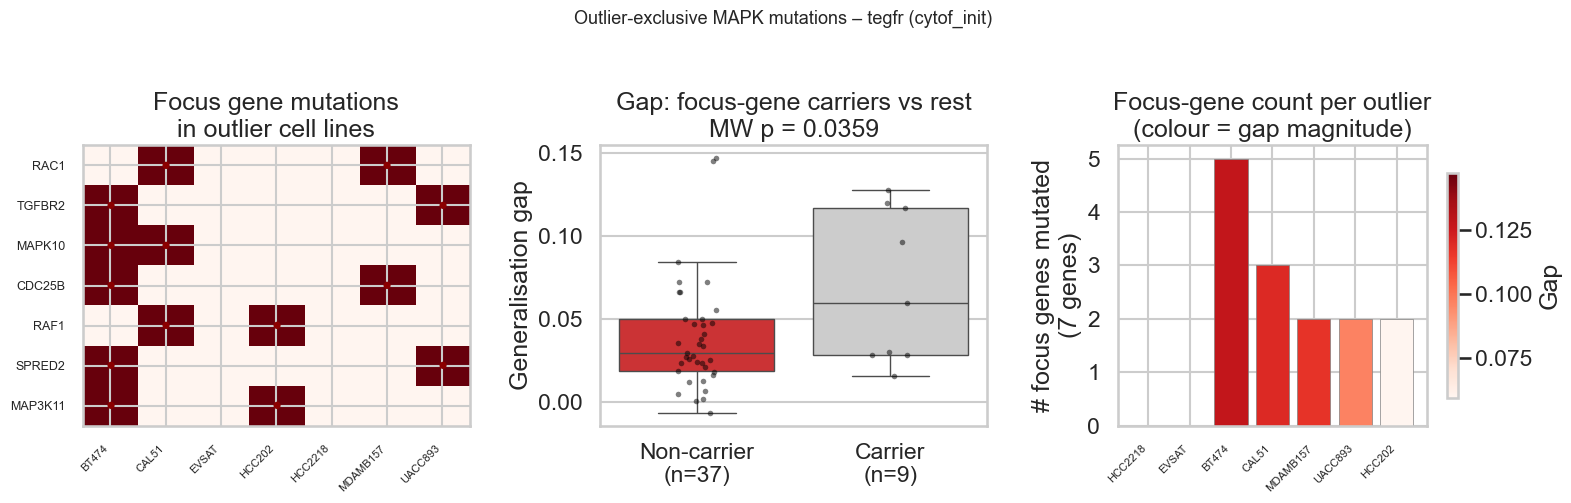

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# Deep dive: outlier-exclusive MAPK mutations (RAC1, TGFBR2, MAPK10 etc.)
# ══════════════════════════════════════════════════════════════════════
# These genes had Fisher p < 0.05 (uncorrected) with mutations found
# *only* in outlier cell lines.  Explore:
#   (a) Which outlier cell lines carry them, and what are the specific variants?
#   (b) Which MAPK pathway gene sets do they belong to?
#   (c) Co-occurrence with other MAPK hits in the same cell lines
#   (d) Gap magnitude for carriers vs non-carriers

# --- 0. Identify outlier-exclusive genes from per-gene results ---
_excl_genes = _gene_ol_df[
    (_gene_ol_df["p_value"] < 0.05) & (_gene_ol_df["n_inlier_mut"] == 0)
]["gene"].tolist()
print(f"Outlier-exclusive MAPK genes (p < 0.05, 0 inlier mutations): {_excl_genes}")

# Also include near-exclusive genes (p < 0.10, ≤1 inlier)
_near_excl = _gene_ol_df[
    (_gene_ol_df["p_value"] < 0.10) & (_gene_ol_df["n_inlier_mut"] <= 1)
    & ~_gene_ol_df["gene"].isin(_excl_genes)
]["gene"].tolist()
if _near_excl:
    print(f"Near-exclusive (p < 0.10, ≤1 inlier): {_near_excl}")
_focus_genes = _excl_genes + _near_excl

# --- 1. Detailed variant table for focus genes ---
print(f"\n{'='*70}")
print("VARIANT DETAILS – outlier-exclusive / near-exclusive MAPK genes")
print(f"{'='*70}")

_focus_muts = _cbio_df[
    _cbio_df["gene"].isin(_focus_genes)
    & _cbio_df["cell_line"].isin(_test_cls)
].copy()
_focus_muts["is_outlier"] = _focus_muts["cell_line"].isin(_outlier_in_cbio)
_focus_muts["overall_gap"] = _focus_muts["cell_line"].map(_overall_gap)
_focus_muts = _focus_muts.sort_values(["gene", "is_outlier", "cell_line"], ascending=[True, False, True])

_display_cols = ["gene", "cell_line", "is_outlier", "mutationType",
                 "proteinChange", "keyword", "variantType", "overall_gap"]
_display_cols = [c for c in _display_cols if c in _focus_muts.columns]
display(_focus_muts[_display_cols].reset_index(drop=True))

# --- 2. Which pathway gene sets contain each focus gene? ---
print(f"\n{'='*70}")
print("PATHWAY MEMBERSHIP of focus genes")
print(f"{'='*70}")

for gene in _focus_genes:
    member_of = [label for gs_name, label in _matched_sets.items()
                 if gene in _gmt.get(gs_name, set())]
    print(f"  {gene:12s} → {', '.join(member_of) if member_of else '(none of the 5 focused sets)'}")

# --- 3. Co-occurrence matrix: which outlier cell lines carry which focus genes? ---
print(f"\n{'='*70}")
print("CO-OCCURRENCE – focus genes × outlier cell lines")
print(f"{'='*70}")

_outlier_list = sorted(_outlier_in_cbio)
_cooc = pd.DataFrame(0, index=_focus_genes, columns=_outlier_list, dtype=int)
for gene in _focus_genes:
    _gene_cls = set(_cbio_df[_cbio_df["gene"] == gene]["cell_line"])
    for cl in _outlier_list:
        if cl in _gene_cls:
            _cooc.loc[gene, cl] = 1

# Add gap as a row for context
_gap_row = pd.DataFrame(
    {cl: [_overall_gap.get(cl, np.nan)] for cl in _outlier_list},
    index=["overall_gap"])
_cooc_display = pd.concat([_cooc, _gap_row])
display(_cooc_display)

# Count how many focus genes each outlier carries
_n_focus_per_cl = _cooc.sum(axis=0)
print(f"\nFocus genes per outlier cell line:")
for cl in _outlier_list:
    n = _n_focus_per_cl[cl]
    gap = _overall_gap.get(cl, np.nan)
    genes = _cooc.columns[_cooc.loc[:, cl] == 0].tolist()  # wrong — fix below
    genes = [g for g in _focus_genes if _cooc.loc[g, cl] == 1]
    print(f"  {cl:20s}  {n} genes  (gap={gap:.4f})  {genes}")

# --- 4. Gap comparison: carriers vs non-carriers of any focus gene ---
_any_focus_cls = set()
for gene in _focus_genes:
    _any_focus_cls |= set(_cbio_df[_cbio_df["gene"] == gene]["cell_line"])
_analysis["has_focus_mut"] = _analysis["cell_line"].isin(_any_focus_cls)

_carrier = _analysis[_analysis["has_focus_mut"]]["overall_gap"]
_noncarr = _analysis[~_analysis["has_focus_mut"]]["overall_gap"]
if len(_carrier) >= 2 and len(_noncarr) >= 2:
    _u_fc, _p_fc = mannwhitneyu(_carrier, _noncarr, alternative="greater")
else:
    _u_fc, _p_fc = np.nan, np.nan

print(f"\n{'='*70}")
print(f"GAP: carriers of any focus gene vs non-carriers")
print(f"{'='*70}")
print(f"  Carriers:     n={len(_carrier)}, median gap={_carrier.median():.4f}, "
      f"mean={_carrier.mean():.4f}")
print(f"  Non-carriers: n={len(_noncarr)}, median gap={_noncarr.median():.4f}, "
      f"mean={_noncarr.mean():.4f}")
print(f"  Mann-Whitney (carrier > non-carrier): U={_u_fc:.0f}, p={_p_fc:.4f}")

# --- 5. Visualisation ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 5a. Heatmap: focus genes × outlier cell lines
ax = axes[0]
_hm_data = _cooc.astype(float)
im = ax.imshow(_hm_data.values, cmap="Reds", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(_outlier_list)))
ax.set_xticklabels([cl.lstrip("c") for cl in _outlier_list], rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(_focus_genes)))
ax.set_yticklabels(_focus_genes, fontsize=9)
ax.set_title("Focus gene mutations\nin outlier cell lines")
# Annotate cells
for i in range(len(_focus_genes)):
    for j in range(len(_outlier_list)):
        if _hm_data.values[i, j] > 0:
            ax.text(j, i, "●", ha="center", va="center", fontsize=12, color="darkred")

# 5b. Boxplot: gap for carriers vs non-carriers
ax = axes[1]
_fc_plot = _analysis.copy()
_fc_plot["Group"] = _fc_plot["has_focus_mut"].map(
    {True: f"Carrier\n(n={len(_carrier)})", False: f"Non-carrier\n(n={len(_noncarr)})"})
sns.boxplot(data=_fc_plot, x="Group", y="overall_gap",
            palette=["#e41a1c", "#cccccc"], ax=ax, showfliers=False)
sns.stripplot(data=_fc_plot, x="Group", y="overall_gap",
              color="black", size=4, alpha=0.5, ax=ax, jitter=True)
ax.set_ylabel("Generalisation gap")
ax.set_xlabel("")
ax.set_title(f"Gap: focus-gene carriers vs rest\nMW p = {_p_fc:.3g}")

# 5c. Bar: # focus genes per outlier, coloured by gap
ax = axes[2]
_ol_gap_sorted = sorted(_outlier_list, key=lambda cl: _overall_gap.get(cl, 0), reverse=True)
_n_fg = [_n_focus_per_cl[cl] for cl in _ol_gap_sorted]
_gaps = [_overall_gap.get(cl, 0) for cl in _ol_gap_sorted]
_norm = plt.Normalize(vmin=min(_gaps), vmax=max(_gaps))
_cmap = plt.cm.Reds
bars = ax.bar(range(len(_ol_gap_sorted)), _n_fg,
              color=[_cmap(_norm(g)) for g in _gaps], edgecolor="grey", linewidth=0.5)
ax.set_xticks(range(len(_ol_gap_sorted)))
ax.set_xticklabels([cl.lstrip("c") for cl in _ol_gap_sorted], rotation=45, ha="right", fontsize=8)
ax.set_ylabel(f"# focus genes mutated\n({len(_focus_genes)} genes)")
ax.set_xlabel("")
ax.set_title("Focus-gene count per outlier\n(colour = gap magnitude)")
sm = plt.cm.ScalarMappable(cmap=_cmap, norm=_norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label="Gap", shrink=0.8)

fig.suptitle(f"Outlier-exclusive MAPK mutations – {_model_label} ({_context})", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

MUTATION TYPE DISTRIBUTION – all genes

Absolute counts:


group,Inlier,Outlier
mutationType,,
Missense_Mutation,13767,3401
Nonsense_Mutation,789,233
Frame_Shift_Del,545,198
Frame_Shift_Ins,493,106
Splice_Site,449,72
Splice_Region,150,29
In_Frame_Del,145,24
Nonstop_Mutation,25,8
Translation_Start_Site,24,4



Fractions:


group,Inlier,Outlier
mutationType,,
Missense_Mutation,0.838,0.834
Nonsense_Mutation,0.048,0.057
Frame_Shift_Del,0.033,0.049
Frame_Shift_Ins,0.030,0.026
Splice_Site,0.027,0.018
Splice_Region,0.009,0.007
In_Frame_Del,0.009,0.006
Nonstop_Mutation,0.002,0.002
Translation_Start_Site,0.001,0.001



MUTATION TYPE DISTRIBUTION – MAPK genes only

Absolute counts:


group,Inlier,Outlier
mutationType,,
Missense_Mutation,291,82
Frame_Shift_Del,18,7
Nonsense_Mutation,25,6
Splice_Site,10,5
Frame_Shift_Ins,19,1
Splice_Region,5,1
In_Frame_Del,5,0
In_Frame_Ins,2,0



Fractions:


group,Inlier,Outlier
mutationType,,
Missense_Mutation,0.776,0.804
Frame_Shift_Del,0.048,0.069
Nonsense_Mutation,0.067,0.059
Splice_Site,0.027,0.049
Frame_Shift_Ins,0.051,0.010
Splice_Region,0.013,0.010
In_Frame_Del,0.013,0.000
In_Frame_Ins,0.005,0.000



Chi² test (all genes): χ²=53.2, df=9, p=2.696e-08
Chi² test (MAPK genes): χ²=7.3, df=7, p=0.4025

FOCUS GENE VARIANT DETAILS


,gene,cell_line,group,mutationType,proteinChange,keyword,variantType
0,CDC25B,cBT474,Outlier,Missense_Mutation,E216K,CDC25B E216 missense,SNP
1,CDC25B,cMDAMB157,Outlier,Missense_Mutation,I132V,CDC25B I132 missense,SNP
2,CDC25B,cHs578T,Inlier,Missense_Mutation,D343N,CDC25B D343 missense,SNP
3,MAP3K11,cBT474,Outlier,Missense_Mutation,E536Q,MAP3K11 E536 missense,SNP
4,MAP3K11,cHCC202,Outlier,Missense_Mutation,D595E,MAP3K11 D595 missense,SNP
5,MAP3K11,cOCUBM,Inlier,Missense_Mutation,E670D,MAP3K11 E670 missense,SNP
6,MAPK10,cBT474,Outlier,Missense_Mutation,R88K,MAPK10 R88 missense,SNP
7,MAPK10,cCAL51,Outlier,Splice_Region,X417_splice,None,SNP
8,RAC1,cCAL51,Outlier,Missense_Mutation,N39S,RAC1 N39 missense,SNP
9,RAC1,cMDAMB157,Outlier,Missense_Mutation,P29S,RAC1 P29 missense,SNP


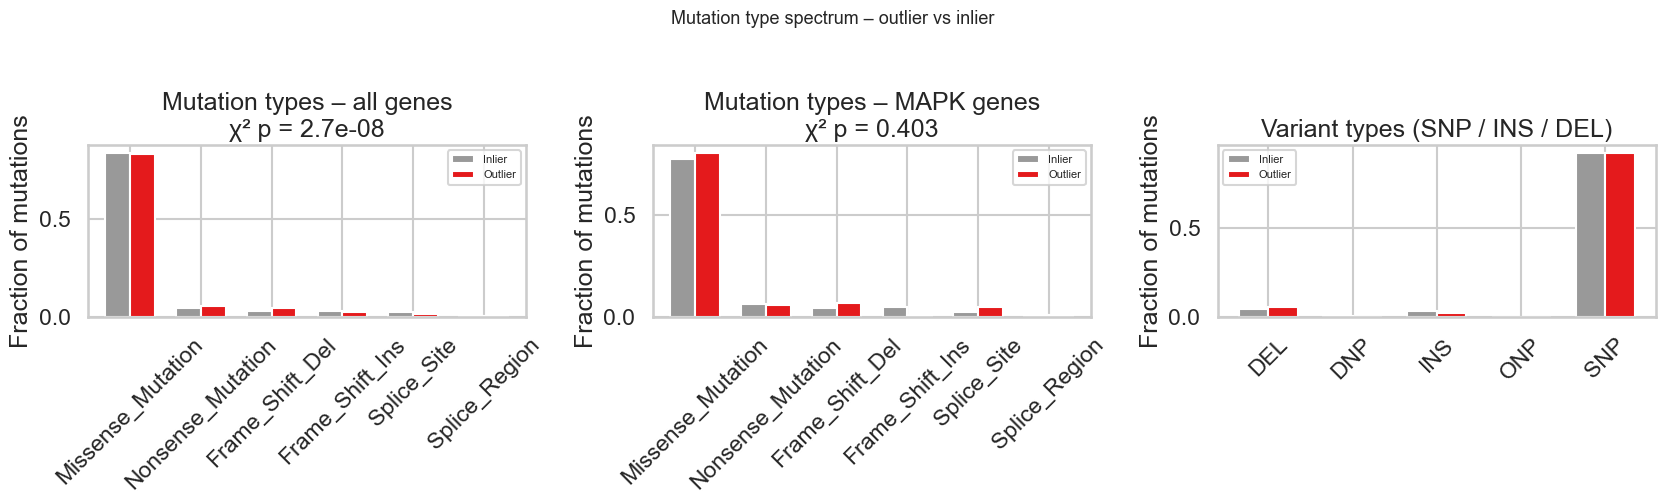

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# Mutation type overview – outlier vs inlier
# ══════════════════════════════════════════════════════════════════════
# Compare the spectrum of mutation types (missense, nonsense, splice, etc.)
# between outlier and inlier cell lines across all genes and MAPK genes.

_cbio_test = _cbio_df[_cbio_df["cell_line"].isin(_test_cls)].copy()
_cbio_test["is_outlier"] = _cbio_test["cell_line"].isin(_outlier_in_cbio)
_cbio_test["group"] = _cbio_test["is_outlier"].map({True: "Outlier", False: "Inlier"})

# --- 1. Overall mutation type distribution ---
print(f"{'='*70}")
print("MUTATION TYPE DISTRIBUTION – all genes")
print(f"{'='*70}")

_mt_counts = _cbio_test.groupby(["group", "mutationType"]).size().unstack(fill_value=0)
_mt_frac = _mt_counts.div(_mt_counts.sum(axis=1), axis=0)

print("\nAbsolute counts:")
display(_mt_counts.T.sort_values("Outlier", ascending=False))
print("\nFractions:")
display(_mt_frac.T.sort_values("Outlier", ascending=False).round(3))

# --- 2. MAPK mutation type distribution ---
print(f"\n{'='*70}")
print("MUTATION TYPE DISTRIBUTION – MAPK genes only")
print(f"{'='*70}")

_cbio_mapk = _cbio_test[_cbio_test["gene"].isin(_MAPK_GENES)]
_mt_mapk = _cbio_mapk.groupby(["group", "mutationType"]).size().unstack(fill_value=0)
_mt_mapk_frac = _mt_mapk.div(_mt_mapk.sum(axis=1), axis=0)

print("\nAbsolute counts:")
display(_mt_mapk.T.sort_values("Outlier", ascending=False))
print("\nFractions:")
display(_mt_mapk_frac.T.sort_values("Outlier", ascending=False).round(3))

# --- 3. Chi-squared test: mutation type spectrum differs? ---
from scipy.stats import chi2_contingency
if _mt_counts.shape[0] == 2 and _mt_counts.shape[1] >= 2:
    _chi2_all, _p_chi2_all, _dof_all, _ = chi2_contingency(_mt_counts)
    print(f"\nChi² test (all genes): χ²={_chi2_all:.1f}, df={_dof_all}, p={_p_chi2_all:.4g}")
if _mt_mapk.shape[0] == 2 and _mt_mapk.shape[1] >= 2:
    _chi2_mapk, _p_chi2_mapk, _dof_mapk, _ = chi2_contingency(_mt_mapk)
    print(f"Chi² test (MAPK genes): χ²={_chi2_mapk:.1f}, df={_dof_mapk}, p={_p_chi2_mapk:.4g}")

# --- 4. Focus genes: variant detail table ---
print(f"\n{'='*70}")
print("FOCUS GENE VARIANT DETAILS")
print(f"{'='*70}")

_focus_detail = _cbio_test[_cbio_test["gene"].isin(_focus_genes)].copy()
_focus_detail = _focus_detail.sort_values(["gene", "is_outlier", "cell_line"],
                                          ascending=[True, False, True])
_detail_cols = ["gene", "cell_line", "group", "mutationType", "proteinChange",
                "keyword", "variantType"]
_detail_cols = [c for c in _detail_cols if c in _focus_detail.columns]
display(_focus_detail[_detail_cols].reset_index(drop=True))

# --- 5. Visualisation ---
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# 5a. Stacked bar: mutation types – all genes
ax = axes[0]
_top_types = _mt_counts.sum().nlargest(6).index.tolist()
_mt_plot = _mt_frac[_top_types].T
_mt_plot.plot(kind="bar", stacked=False, ax=ax, width=0.7,
              color={"Outlier": "#e41a1c", "Inlier": "#999999"})
ax.set_ylabel("Fraction of mutations")
ax.set_xlabel("")
ax.set_title(f"Mutation types – all genes\nχ² p = {_p_chi2_all:.3g}")
ax.legend(fontsize=8)
ax.tick_params(axis="x", rotation=45)

# 5b. Stacked bar: mutation types – MAPK genes
ax = axes[1]
_top_mapk = _mt_mapk.sum().nlargest(6).index.tolist()
_mt_mapk_plot = _mt_mapk_frac[_top_mapk].T
_mt_mapk_plot.plot(kind="bar", stacked=False, ax=ax, width=0.7,
                   color={"Outlier": "#e41a1c", "Inlier": "#999999"})
ax.set_ylabel("Fraction of mutations")
ax.set_xlabel("")
ax.set_title(f"Mutation types – MAPK genes\nχ² p = {_p_chi2_mapk:.3g}")
ax.legend(fontsize=8)
ax.tick_params(axis="x", rotation=45)

# 5c. Variant type distribution
_vt = _cbio_test.groupby(["group", "variantType"]).size().unstack(fill_value=0)
_vt_frac = _vt.div(_vt.sum(axis=1), axis=0)
ax = axes[2]
_vt_frac.T.plot(kind="bar", stacked=False, ax=ax, width=0.7,
                color={"Outlier": "#e41a1c", "Inlier": "#999999"})
ax.set_ylabel("Fraction of mutations")
ax.set_xlabel("")
ax.set_title("Variant types (SNP / INS / DEL)")
ax.legend(fontsize=8)
ax.tick_params(axis="x", rotation=45)

fig.suptitle("Mutation type spectrum – outlier vs inlier", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()


LoF ENRICHMENT – All genes
  LoF types: ['Frame_Shift_Del', 'Frame_Shift_Ins', 'Nonsense_Mutation', 'Splice_Site']

  Binary (any LoF mutation):
    Outliers: 7/7 = 100%
    Inliers:  39/39 = 100%
    Fisher exact: OR=nan, p=1.0000

  LoF count (burden):
    Outliers: median=58, mean=87.0
    Inliers:  median=41, mean=58.4
    MW (outlier > inlier): U=202, p=0.0233

  LoF fraction (LoF / total mutations):
    Outliers: median=0.123, mean=0.140
    Inliers:  median=0.132, mean=0.138
    MW (outlier > inlier): U=88, p=0.9318

  Correlation with gap:
    LoF count vs gap: ρ=+0.168, p=0.2655
    LoF fraction vs gap: ρ=-0.252, p=0.0909

LoF ENRICHMENT – MAPK genes (355)
  LoF types: ['Frame_Shift_Del', 'Frame_Shift_Ins', 'Nonsense_Mutation', 'Splice_Site']

  Binary (any LoF mutation):
    Outliers: 7/7 = 100%
    Inliers:  29/39 = 74%
    Fisher exact: OR=inf, p=0.3191

  LoF count (burden):
    Outliers: median=3, mean=2.7
    Inliers:  median=1, mean=1.8
    MW (outlier > inlier): U=202

,cell_line,is_outlier,n_lof_all,n_total,lof_frac_all,n_lof_mapk,lof_frac_mapk,overall_gap
2,cBT474,True,127,1019,0.1246,1,0.0385,0.1277
43,cUACC893,True,44,402,0.1095,3,0.4286,0.0964
22,cHCC2218,True,43,373,0.1153,3,0.3750,0.1470
6,cCAL51,True,219,822,0.2664,4,0.1818,0.1199
21,cHCC202,True,63,477,0.1321,4,0.2500,0.0594
30,cMDAMB157,True,55,447,0.1230,3,0.2308,0.1167
11,cEVSAT,True,58,536,0.1082,1,0.1000,0.1453
0,cAU565,False,61,559,0.1091,0,0.0000,0.0497
34,cMDAMB415,False,95,758,0.1253,3,0.2000,0.0470
28,cMCF7,False,58,494,0.1174,1,0.1111,0.0211


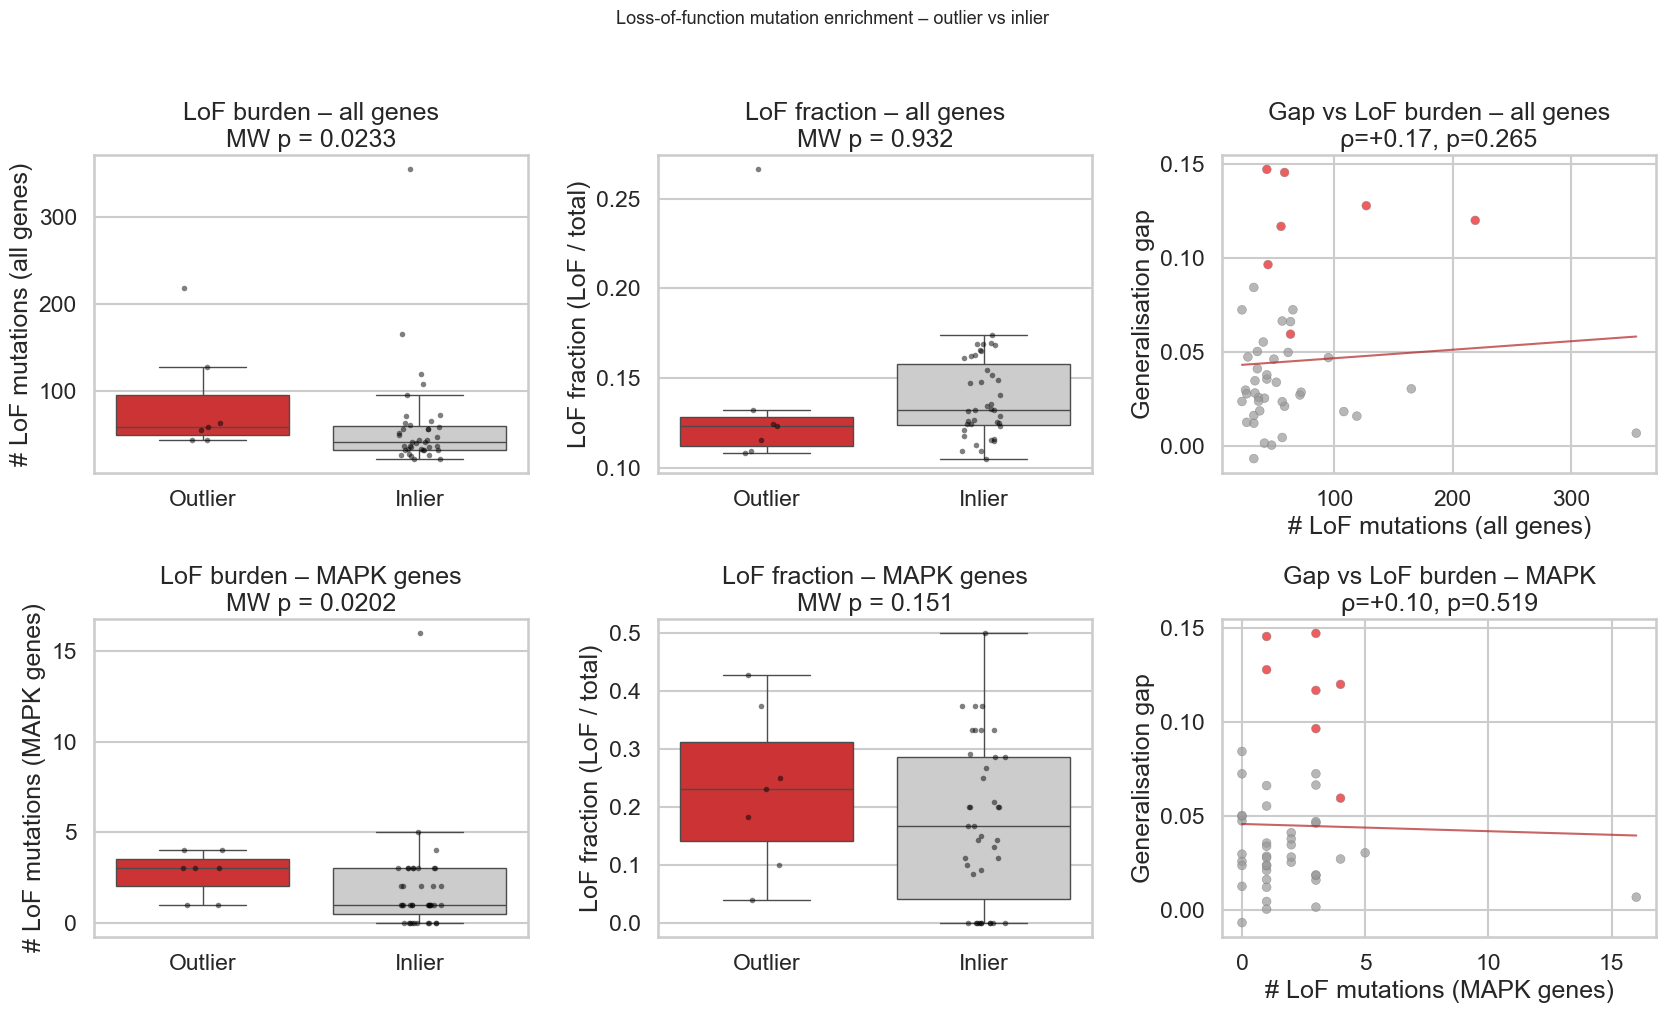


LoF ENRICHMENT SUMMARY


,label,or_fisher,p_fisher,p_count,p_frac,rho_gap,p_gap,rho_frac,p_frac_gap
0,All genes,NaN,1.0000,0.0233,0.9318,0.1676,0.2655,-0.2522,0.0909
1,MAPK genes (355),inf,0.3191,0.0202,0.1513,0.0974,0.5194,0.0153,0.9195


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# Loss-of-function (LoF) mutation enrichment – outlier vs inlier
# ══════════════════════════════════════════════════════════════════════
# Canonical LoF: Nonsense, Frameshift, Splice_Site
# Tests: Fisher exact (any LoF), Mann-Whitney (LoF burden), Spearman (LoF vs gap)
# Scope: all genes and MAPK genes

from scipy.stats import fisher_exact, mannwhitneyu, spearmanr

_LOF_TYPES = {"Nonsense_Mutation", "Frame_Shift_Del", "Frame_Shift_Ins", "Splice_Site"}

# Tag each cBioPortal mutation as LoF or not
_cbio_test = _cbio_df[_cbio_df["cell_line"].isin(_test_cls)].copy()
_cbio_test["is_outlier"] = _cbio_test["cell_line"].isin(_outlier_in_cbio)
_cbio_test["is_lof"] = _cbio_test["mutationType"].isin(_LOF_TYPES)

# ── helper: run LoF enrichment on a mutation subset ──────────────────
def _lof_enrichment(mutations, outlier_cls, inlier_cls, label):
    """Run LoF enrichment tests on the given mutation DataFrame."""
    # -- LoF burden per cell line (count of LoF mutations) --
    lof = mutations[mutations["is_lof"]]
    lof_per_cl = lof.groupby("cell_line").size().rename("n_lof")
    # Ensure every test cell line has a count (0 if no LoF)
    all_cls = sorted(outlier_cls | inlier_cls)
    burden = pd.DataFrame({"cell_line": all_cls})
    burden["n_lof"] = burden["cell_line"].map(lof_per_cl).fillna(0).astype(int)
    burden["is_outlier"] = burden["cell_line"].isin(outlier_cls)

    # Total mutations per cell line (for LoF fraction)
    total_per_cl = mutations.groupby("cell_line").size().rename("n_total")
    burden["n_total"] = burden["cell_line"].map(total_per_cl).fillna(0).astype(int)
    burden["lof_frac"] = (burden["n_lof"] / burden["n_total"]).fillna(0)

    out = burden[burden["is_outlier"]]
    inl = burden[~burden["is_outlier"]]

    # -- 1. Fisher exact: any LoF mutation --
    out_has = (out["n_lof"] > 0).sum()
    out_no  = len(out) - out_has
    in_has  = (inl["n_lof"] > 0).sum()
    in_no   = len(inl) - in_has
    ct = np.array([[out_has, out_no], [in_has, in_no]])
    odds_f, p_f = fisher_exact(ct)

    # -- 2. Mann-Whitney: LoF count --
    if out["n_lof"].sum() + inl["n_lof"].sum() > 0:
        u_cnt, p_cnt = mannwhitneyu(out["n_lof"], inl["n_lof"], alternative="greater")
    else:
        u_cnt, p_cnt = np.nan, 1.0

    # -- 3. Mann-Whitney: LoF fraction --
    if out["lof_frac"].sum() + inl["lof_frac"].sum() > 0:
        u_frac, p_frac = mannwhitneyu(out["lof_frac"], inl["lof_frac"], alternative="greater")
    else:
        u_frac, p_frac = np.nan, 1.0

    # -- 4. Spearman: LoF count vs gap --
    burden["overall_gap"] = burden["cell_line"].map(_overall_gap)
    rho_gap, p_gap = spearmanr(burden["overall_gap"].dropna(),
                                burden.loc[burden["overall_gap"].notna(), "n_lof"])
    rho_frac, p_frac_gap = spearmanr(
        burden.loc[burden["overall_gap"].notna(), "overall_gap"],
        burden.loc[burden["overall_gap"].notna(), "lof_frac"])

    print(f"\n{'='*70}")
    print(f"LoF ENRICHMENT – {label}")
    print(f"  LoF types: {sorted(_LOF_TYPES)}")
    print(f"{'='*70}")
    print(f"\n  Binary (any LoF mutation):")
    print(f"    Outliers: {out_has}/{len(out)} = {out_has/len(out):.0%}")
    print(f"    Inliers:  {in_has}/{len(inl)} = {in_has/len(inl):.0%}")
    print(f"    Fisher exact: OR={odds_f:.2f}, p={p_f:.4f}")
    print(f"\n  LoF count (burden):")
    print(f"    Outliers: median={out['n_lof'].median():.0f}, "
          f"mean={out['n_lof'].mean():.1f}")
    print(f"    Inliers:  median={inl['n_lof'].median():.0f}, "
          f"mean={inl['n_lof'].mean():.1f}")
    print(f"    MW (outlier > inlier): U={u_cnt:.0f}, p={p_cnt:.4f}")
    print(f"\n  LoF fraction (LoF / total mutations):")
    print(f"    Outliers: median={out['lof_frac'].median():.3f}, "
          f"mean={out['lof_frac'].mean():.3f}")
    print(f"    Inliers:  median={inl['lof_frac'].median():.3f}, "
          f"mean={inl['lof_frac'].mean():.3f}")
    print(f"    MW (outlier > inlier): U={u_frac:.0f}, p={p_frac:.4f}")
    print(f"\n  Correlation with gap:")
    print(f"    LoF count vs gap: ρ={rho_gap:+.3f}, p={p_gap:.4f}")
    print(f"    LoF fraction vs gap: ρ={rho_frac:+.3f}, p={p_frac_gap:.4f}")

    return burden, {
        "label": label,
        "or_fisher": odds_f, "p_fisher": p_f,
        "u_count": u_cnt, "p_count": p_cnt,
        "u_frac": u_frac, "p_frac": p_frac,
        "rho_gap": rho_gap, "p_gap": p_gap,
        "rho_frac": rho_frac, "p_frac_gap": p_frac_gap,
    }

# ── Run for all genes and MAPK genes ────────────────────────────────
_burden_all, _stats_all = _lof_enrichment(
    _cbio_test, _outlier_in_cbio, _inlier_in_cbio, "All genes")

_cbio_mapk = _cbio_test[_cbio_test["gene"].isin(_MAPK_GENES)]
_burden_mapk, _stats_mapk = _lof_enrichment(
    _cbio_mapk, _outlier_in_cbio, _inlier_in_cbio, f"MAPK genes ({len(_MAPK_GENES)})")

# ── Per-cell-line LoF detail table ───────────────────────────────────
_lof_detail = _burden_all.merge(
    _burden_mapk[["cell_line", "n_lof", "lof_frac"]],
    on="cell_line", suffixes=("_all", "_mapk"))
_lof_detail = _lof_detail.sort_values("is_outlier", ascending=False)
print(f"\n{'='*70}")
print("PER-CELL-LINE LoF SUMMARY (top outliers + sample inliers)")
print(f"{'='*70}")
_cols_show = ["cell_line", "is_outlier", "n_lof_all", "n_total",
              "lof_frac_all", "n_lof_mapk", "lof_frac_mapk", "overall_gap"]
display(_lof_detail[_cols_show].head(20).round(4))

# ── Visualisation: 2×3 grid ─────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(17, 10))

_burden_all["Group"] = _burden_all["is_outlier"].map({True: "Outlier", False: "Inlier"})
_burden_mapk["Group"] = _burden_mapk["is_outlier"].map({True: "Outlier", False: "Inlier"})

# Row 1: All genes
# 1a. Boxplot: LoF count
ax = axes[0, 0]
sns.boxplot(data=_burden_all, x="Group", y="n_lof",
            order=["Outlier", "Inlier"],
            palette={"Outlier": "#e41a1c", "Inlier": "#cccccc"},
            ax=ax, showfliers=False)
sns.stripplot(data=_burden_all, x="Group", y="n_lof",
              order=["Outlier", "Inlier"],
              color="black", size=4, alpha=0.5, ax=ax, jitter=True)
ax.set_ylabel("# LoF mutations (all genes)")
ax.set_xlabel("")
ax.set_title(f"LoF burden – all genes\nMW p = {_stats_all['p_count']:.3g}")

# 1b. Boxplot: LoF fraction
ax = axes[0, 1]
sns.boxplot(data=_burden_all, x="Group", y="lof_frac",
            order=["Outlier", "Inlier"],
            palette={"Outlier": "#e41a1c", "Inlier": "#cccccc"},
            ax=ax, showfliers=False)
sns.stripplot(data=_burden_all, x="Group", y="lof_frac",
              order=["Outlier", "Inlier"],
              color="black", size=4, alpha=0.5, ax=ax, jitter=True)
ax.set_ylabel("LoF fraction (LoF / total)")
ax.set_xlabel("")
ax.set_title(f"LoF fraction – all genes\nMW p = {_stats_all['p_frac']:.3g}")

# 1c. Scatter: LoF count vs gap
ax = axes[0, 2]
ax.scatter(_burden_all["n_lof"], _burden_all["overall_gap"],
           s=40, alpha=0.7, edgecolor="grey", linewidth=0.4,
           c=_burden_all["is_outlier"].map({True: "#e41a1c", False: "#999999"}))
z = np.polyfit(_burden_all["n_lof"], _burden_all["overall_gap"], 1)
xl = np.linspace(_burden_all["n_lof"].min(), _burden_all["n_lof"].max(), 50)
ax.plot(xl, np.polyval(z, xl), color="firebrick", linewidth=1.5, alpha=0.7)
ax.set_xlabel("# LoF mutations (all genes)")
ax.set_ylabel("Generalisation gap")
ax.set_title(f"Gap vs LoF burden – all genes\nρ={_stats_all['rho_gap']:+.2f}, "
             f"p={_stats_all['p_gap']:.3g}")

# Row 2: MAPK genes
# 2a. Boxplot: LoF count
ax = axes[1, 0]
sns.boxplot(data=_burden_mapk, x="Group", y="n_lof",
            order=["Outlier", "Inlier"],
            palette={"Outlier": "#e41a1c", "Inlier": "#cccccc"},
            ax=ax, showfliers=False)
sns.stripplot(data=_burden_mapk, x="Group", y="n_lof",
              order=["Outlier", "Inlier"],
              color="black", size=4, alpha=0.5, ax=ax, jitter=True)
ax.set_ylabel("# LoF mutations (MAPK genes)")
ax.set_xlabel("")
ax.set_title(f"LoF burden – MAPK genes\nMW p = {_stats_mapk['p_count']:.3g}")

# 2b. Boxplot: LoF fraction
ax = axes[1, 1]
sns.boxplot(data=_burden_mapk, x="Group", y="lof_frac",
            order=["Outlier", "Inlier"],
            palette={"Outlier": "#e41a1c", "Inlier": "#cccccc"},
            ax=ax, showfliers=False)
sns.stripplot(data=_burden_mapk, x="Group", y="lof_frac",
              order=["Outlier", "Inlier"],
              color="black", size=4, alpha=0.5, ax=ax, jitter=True)
ax.set_ylabel("LoF fraction (LoF / total)")
ax.set_xlabel("")
ax.set_title(f"LoF fraction – MAPK genes\nMW p = {_stats_mapk['p_frac']:.3g}")

# 2c. Scatter: MAPK LoF count vs gap
ax = axes[1, 2]
ax.scatter(_burden_mapk["n_lof"], _burden_mapk["overall_gap"],
           s=40, alpha=0.7, edgecolor="grey", linewidth=0.4,
           c=_burden_mapk["is_outlier"].map({True: "#e41a1c", False: "#999999"}))
_mapk_lof_vals = _burden_mapk["n_lof"]
if _mapk_lof_vals.max() > _mapk_lof_vals.min():
    z = np.polyfit(_mapk_lof_vals, _burden_mapk["overall_gap"], 1)
    xl = np.linspace(_mapk_lof_vals.min(), _mapk_lof_vals.max(), 50)
    ax.plot(xl, np.polyval(z, xl), color="firebrick", linewidth=1.5, alpha=0.7)
ax.set_xlabel("# LoF mutations (MAPK genes)")
ax.set_ylabel("Generalisation gap")
ax.set_title(f"Gap vs LoF burden – MAPK\nρ={_stats_mapk['rho_gap']:+.2f}, "
             f"p={_stats_mapk['p_gap']:.3g}")

fig.suptitle("Loss-of-function mutation enrichment – outlier vs inlier",
             fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

# ── Summary table ────────────────────────────────────────────────────
_summary_lof = pd.DataFrame([_stats_all, _stats_mapk])
_summary_lof = _summary_lof[["label", "or_fisher", "p_fisher",
                              "p_count", "p_frac", "rho_gap", "p_gap",
                              "rho_frac", "p_frac_gap"]]
print(f"\n{'='*70}")
print("LoF ENRICHMENT SUMMARY")
print(f"{'='*70}")
display(_summary_lof.round(4))

CMP CANCER DRIVER MUTATIONS – outlier vs inlier
  Cell lines with CMP driver data: 44/46

  Binary (any CMP driver):
    Outliers: 7/7 = 100%
    Inliers:  37/39 = 95%
    Fisher exact: OR=inf, p=1.0000

  Driver count (burden):
    Outliers: median=7, mean=8.0
    Inliers:  median=5, mean=5.6
    MW (outlier > inlier): U=164, p=0.1984

  Correlation with gap:
    Spearman: ρ=+0.204, p=0.1730

OUTLIER CELL LINES – CMP cancer drivers
  cHCC2218        (gap=0.1470, n_drivers= 3): CIC, MSH6, TP53
  cEVSAT          (gap=0.1453, n_drivers= 7): CDH1, EGFR, PCDH17, PTEN, SPEN, TP53, ZFHX3
  cBT474          (gap=0.1277, n_drivers=12): AFF3, BRCA2, FANCA, HNF1A, KMT2B, MB21D2, PABPC1, PIK3CA, RHOA, RUNX1T1, TP53, TPM3
  cCAL51          (gap=0.1199, n_drivers=20): ARID1A, ARID1B, ATRX, BCL2L12, BCOR, BCORL1, BRCA2, JAK1, KMT2A, MAP2K4, MAX, NFATC2, PIK3CA, PTEN, RPL22, RRAS2, RXRA, SMARCA4, ZFHX3, ZNF626
  cMDAMB157       (gap=0.1167, n_drivers= 4): ATM, JAK3, NF1, ZEB1
  cUACC893        (gap=0.

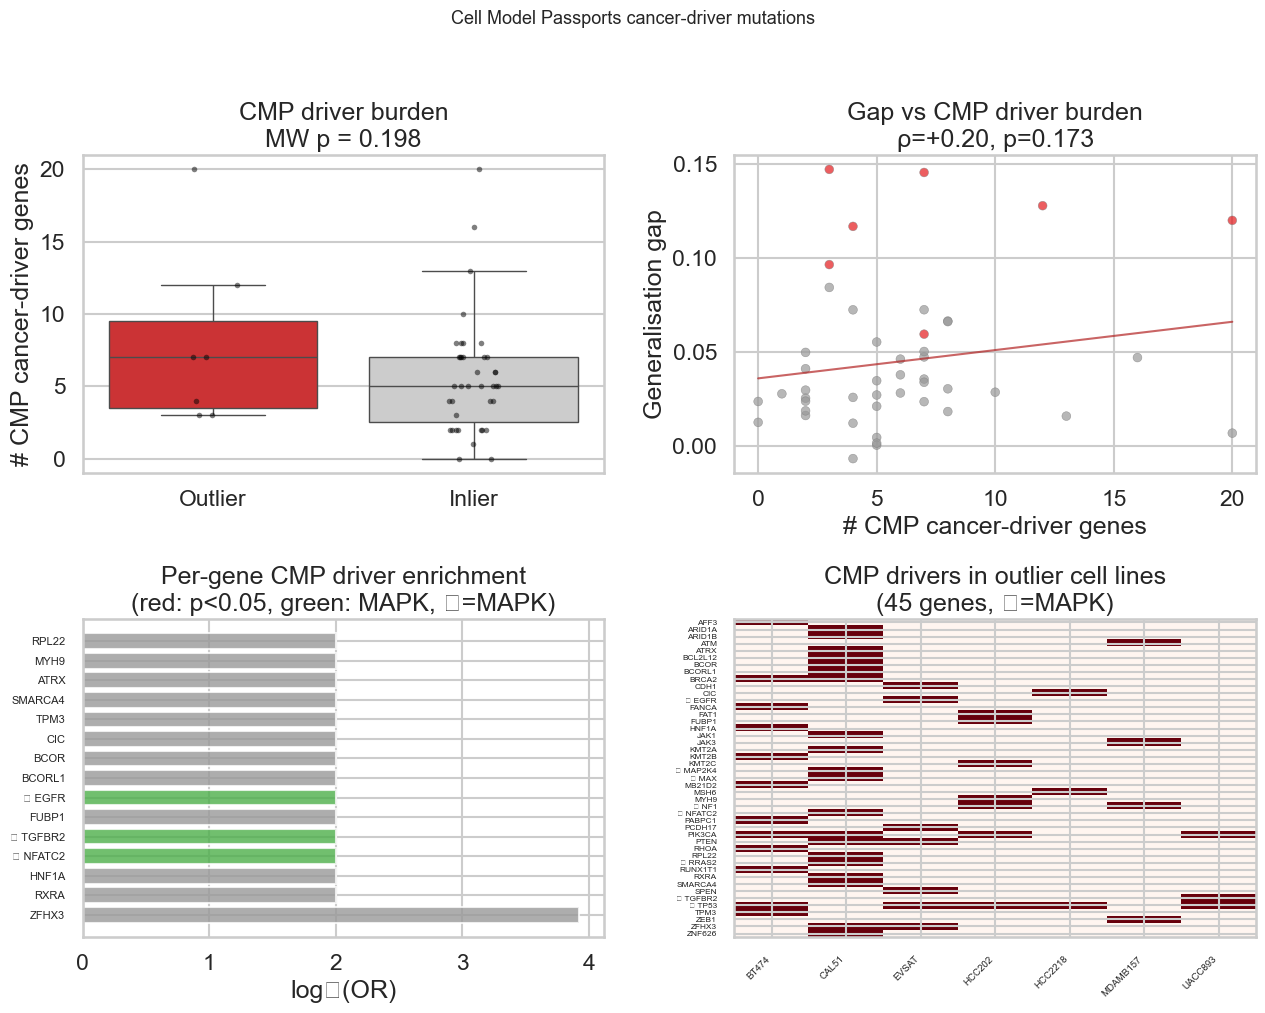


PER-GENE DRIVER ENRICHMENT TABLE (all, sorted by p-value)


,gene,in_MAPK,n_total,n_outlier,n_inlier,outlier_frac,inlier_frac,odds_ratio,p_value,q_value
148,ZFHX3,False,3,2,1,0.2857,0.0256,15.2,0.0563,0.9435
125,RXRA,False,1,1,0,0.1429,0.0000,inf,0.1522,0.9435
63,HNF1A,False,1,1,0,0.1429,0.0000,inf,0.1522,0.9435
95,NFATC2,True,1,1,0,0.1429,0.0000,inf,0.1522,0.9435
140,TGFBR2,True,1,1,0,0.1429,0.0000,inf,0.1522,0.9435
...,...,...,...,...,...,...,...,...,...,...
46,ERBB4,False,1,0,1,0.0000,0.0256,0.0,1.0000,1.0000
45,EPHA7,False,1,0,1,0.0000,0.0256,0.0,1.0000,1.0000
44,EPHA3,False,1,0,1,0.0000,0.0256,0.0,1.0000,1.0000
61,HLA-A,False,5,0,5,0.0000,0.1282,0.0,1.0000,1.0000


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# Cell Model Passports (CMP) cancer driver mutations – outlier vs inlier
# ══════════════════════════════════════════════════════════════════════
# _cmp_drivers: dict cell_line → list of driver gene symbols (from Sanger)
# Compare: driver burden, binary enrichment (any driver), per-gene Fisher,
#          overlap with MAPK pathway, correlation with gap.

from scipy.stats import fisher_exact, mannwhitneyu, spearmanr
from statsmodels.stats.multitest import multipletests

# ── 1. Build per-cell-line driver burden table ───────────────────────
_drv = pd.DataFrame({"cell_line": sorted(_test_cls)})
_drv["is_outlier"] = _drv["cell_line"].isin(_outlier_in_cbio)

# Number of CMP cancer-driver genes per cell line
_drv["n_drivers"] = _drv["cell_line"].map(
    lambda cl: len(set(_cmp_drivers.get(cl, []))))
_drv["has_driver"] = _drv["n_drivers"] > 0
_drv["overall_gap"] = _drv["cell_line"].map(_overall_gap)

# List of driver genes per cell line (for display)
_drv["driver_genes"] = _drv["cell_line"].map(
    lambda cl: ", ".join(sorted(set(_cmp_drivers.get(cl, [])))))

_out_drv = _drv[_drv["is_outlier"]]
_in_drv  = _drv[~_drv["is_outlier"]]

print(f"{'='*70}")
print("CMP CANCER DRIVER MUTATIONS – outlier vs inlier")
print(f"{'='*70}")
print(f"  Cell lines with CMP driver data: "
      f"{(_drv['n_drivers'] > 0).sum()}/{len(_drv)}")

# ── 2. Binary enrichment: any driver mutation ────────────────────────
_ct_drv = np.array([
    [(out_has := _out_drv["has_driver"].sum()),
     len(_out_drv) - out_has],
    [(in_has := _in_drv["has_driver"].sum()),
     len(_in_drv) - in_has],
])
_or_drv, _p_drv = fisher_exact(_ct_drv)
print(f"\n  Binary (any CMP driver):")
print(f"    Outliers: {out_has}/{len(_out_drv)} = {out_has/len(_out_drv):.0%}")
print(f"    Inliers:  {in_has}/{len(_in_drv)} = {in_has/len(_in_drv):.0%}")
print(f"    Fisher exact: OR={_or_drv:.2f}, p={_p_drv:.4f}")

# ── 3. Driver burden (count) ────────────────────────────────────────
_u_drv, _p_u_drv = mannwhitneyu(
    _out_drv["n_drivers"], _in_drv["n_drivers"], alternative="greater")
print(f"\n  Driver count (burden):")
print(f"    Outliers: median={_out_drv['n_drivers'].median():.0f}, "
      f"mean={_out_drv['n_drivers'].mean():.1f}")
print(f"    Inliers:  median={_in_drv['n_drivers'].median():.0f}, "
      f"mean={_in_drv['n_drivers'].mean():.1f}")
print(f"    MW (outlier > inlier): U={_u_drv:.0f}, p={_p_u_drv:.4f}")

# ── 4. Spearman: driver count vs gap ────────────────────────────────
_valid = _drv.dropna(subset=["overall_gap"])
_rho_drv, _p_rho_drv = spearmanr(_valid["overall_gap"], _valid["n_drivers"])
print(f"\n  Correlation with gap:")
print(f"    Spearman: ρ={_rho_drv:+.3f}, p={_p_rho_drv:.4f}")

# ── 5. Outlier cell line driver detail ───────────────────────────────
print(f"\n{'='*70}")
print("OUTLIER CELL LINES – CMP cancer drivers")
print(f"{'='*70}")
for _, row in _out_drv.sort_values("overall_gap", ascending=False).iterrows():
    cl = row["cell_line"]
    genes = row["driver_genes"] or "(no CMP data)"
    print(f"  {cl:15s} (gap={row['overall_gap']:.4f}, "
          f"n_drivers={row['n_drivers']:2d}): {genes}")

# ── 6. Per-gene enrichment (Fisher exact) ────────────────────────────
# Pool all driver genes across test cell lines
_all_driver_genes = set()
for cl in _test_cls:
    _all_driver_genes.update(_cmp_drivers.get(cl, []))
print(f"\n{'='*70}")
print(f"PER-GENE CMP DRIVER ENRICHMENT ({len(_all_driver_genes)} driver genes)")
print(f"{'='*70}")

_gene_drv_results = []
for gene in sorted(_all_driver_genes):
    _cls_with = {cl for cl in _test_cls if gene in _cmp_drivers.get(cl, [])}
    _out_yes = len(_cls_with & _outlier_in_cbio)
    _out_no  = len(_outlier_in_cbio) - _out_yes
    _in_yes  = len(_cls_with & _inlier_in_cbio)
    _in_no   = len(_inlier_in_cbio) - _in_yes
    ct = np.array([[_out_yes, _out_no], [_in_yes, _in_no]])
    odds, p = fisher_exact(ct)
    _gene_drv_results.append({
        "gene": gene, "n_total": len(_cls_with),
        "n_outlier": _out_yes, "n_inlier": _in_yes,
        "outlier_frac": _out_yes / len(_outlier_in_cbio),
        "inlier_frac": _in_yes / len(_inlier_in_cbio),
        "odds_ratio": odds, "p_value": p,
    })

_gene_drv_df = pd.DataFrame(_gene_drv_results).sort_values("p_value")
_gene_drv_df["q_value"] = multipletests(_gene_drv_df["p_value"], method="fdr_bh")[1]

# Flag MAPK pathway membership
_gene_drv_df["in_MAPK"] = _gene_drv_df["gene"].isin(_MAPK_GENES)

# Show top genes
for _, row in _gene_drv_df.head(20).iterrows():
    sig = ("***" if row["q_value"] < 0.001 else "**" if row["q_value"] < 0.01
           else "*" if row["q_value"] < 0.05 else "†" if row["p_value"] < 0.05 else "")
    mapk_flag = " [MAPK]" if row["in_MAPK"] else ""
    print(f"  {row['gene']:12s} (n={row['n_total']:2.0f}): "
          f"out={row['outlier_frac']:.0%} vs in={row['inlier_frac']:.0%} | "
          f"OR={row['odds_ratio']:.2f}, p={row['p_value']:.3g}, "
          f"q={row['q_value']:.3g} {sig}{mapk_flag}")

# ── 7. Overlap: CMP drivers × MAPK pathway ──────────────────────────
_mapk_drivers = _all_driver_genes & set(_MAPK_GENES)
print(f"\n{'='*70}")
print(f"CMP DRIVER GENES IN MAPK PATHWAY: {len(_mapk_drivers)}")
print(f"{'='*70}")
if _mapk_drivers:
    for gene in sorted(_mapk_drivers):
        _cls_with = {cl for cl in _test_cls if gene in _cmp_drivers.get(cl, [])}
        _out_cls = sorted(_cls_with & _outlier_in_cbio)
        _in_cls  = sorted(_cls_with & _inlier_in_cbio)
        print(f"  {gene:12s}: outlier={_out_cls or []}, inlier={_in_cls or []}")

# ── 8. Outlier-exclusive driver genes ────────────────────────────────
_outlier_only_drivers = []
for gene in sorted(_all_driver_genes):
    _cls_with = {cl for cl in _test_cls if gene in _cmp_drivers.get(cl, [])}
    if _cls_with and _cls_with <= _outlier_in_cbio:
        _outlier_only_drivers.append(gene)
if _outlier_only_drivers:
    print(f"\nOutlier-exclusive CMP driver genes ({len(_outlier_only_drivers)}):")
    for gene in _outlier_only_drivers:
        _cls_with = sorted({cl for cl in _test_cls if gene in _cmp_drivers.get(cl, [])})
        mapk_flag = " [MAPK]" if gene in _MAPK_GENES else ""
        print(f"  {gene:12s}: {_cls_with}{mapk_flag}")

# ── 9. Visualisation: 2×2 grid ──────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

_drv["Group"] = _drv["is_outlier"].map({True: "Outlier", False: "Inlier"})

# 9a. Boxplot: driver count
ax = axes[0, 0]
sns.boxplot(data=_drv, x="Group", y="n_drivers",
            order=["Outlier", "Inlier"],
            palette={"Outlier": "#e41a1c", "Inlier": "#cccccc"},
            ax=ax, showfliers=False)
sns.stripplot(data=_drv, x="Group", y="n_drivers",
              order=["Outlier", "Inlier"],
              color="black", size=4, alpha=0.5, ax=ax, jitter=True)
ax.set_ylabel("# CMP cancer-driver genes")
ax.set_xlabel("")
ax.set_title(f"CMP driver burden\nMW p = {_p_u_drv:.3g}")

# 9b. Scatter: driver count vs gap
ax = axes[0, 1]
ax.scatter(_drv["n_drivers"], _drv["overall_gap"],
           s=40, alpha=0.7, edgecolor="grey", linewidth=0.4,
           c=_drv["is_outlier"].map({True: "#e41a1c", False: "#999999"}))
if _drv["n_drivers"].max() > _drv["n_drivers"].min():
    z = np.polyfit(_drv["n_drivers"], _drv["overall_gap"], 1)
    xl = np.linspace(_drv["n_drivers"].min(), _drv["n_drivers"].max(), 50)
    ax.plot(xl, np.polyval(z, xl), color="firebrick", linewidth=1.5, alpha=0.7)
ax.set_xlabel("# CMP cancer-driver genes")
ax.set_ylabel("Generalisation gap")
ax.set_title(f"Gap vs CMP driver burden\nρ={_rho_drv:+.2f}, p={_p_rho_drv:.3g}")

# 9c. Per-gene forest plot (top 15 by p-value)
ax = axes[1, 0]
_top_genes = _gene_drv_df.head(15).sort_values("odds_ratio", ascending=True).copy()
y = np.arange(len(_top_genes))
colors = ["#e41a1c" if p < 0.05 else "#4daf4a" if mapk else "#999999"
          for p, mapk in zip(_top_genes["p_value"], _top_genes["in_MAPK"])]
log2or = np.log2(_top_genes["odds_ratio"].clip(lower=0.1).replace([np.inf], 4))
ax.barh(y, log2or, color=colors, alpha=0.8)
ax.set_yticks(y)
labels = [f"{'★ ' if m else ''}{g}" for g, m in
          zip(_top_genes["gene"], _top_genes["in_MAPK"])]
ax.set_yticklabels(labels, fontsize=8)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_xlabel("log₂(OR)")
ax.set_title("Per-gene CMP driver enrichment\n(red: p<0.05, green: MAPK, ★=MAPK)")

# 9d. Heatmap: driver genes × outlier cell lines
ax = axes[1, 1]
_outlier_list = sorted(_outlier_in_cbio)
_drv_genes_in_outliers = set()
for cl in _outlier_list:
    _drv_genes_in_outliers.update(_cmp_drivers.get(cl, []))
_drv_genes_sorted = sorted(_drv_genes_in_outliers)
if _drv_genes_sorted:
    _hm_data = pd.DataFrame(0, index=_drv_genes_sorted, columns=_outlier_list)
    for cl in _outlier_list:
        for g in _cmp_drivers.get(cl, []):
            if g in _hm_data.index:
                _hm_data.loc[g, cl] = 1
    # Only show genes present in ≥1 outlier
    _hm_data = _hm_data.loc[_hm_data.sum(axis=1) > 0]
    im = ax.imshow(_hm_data.values, cmap="Reds", aspect="auto",
                   vmin=0, vmax=1)
    ax.set_xticks(range(len(_hm_data.columns)))
    ax.set_xticklabels([c.replace("c","",1) for c in _hm_data.columns],
                       rotation=45, ha="right", fontsize=7)
    ax.set_yticks(range(len(_hm_data.index)))
    # Mark MAPK genes with ★
    ylabels = [f"{'★ ' if g in _MAPK_GENES else ''}{g}"
               for g in _hm_data.index]
    ax.set_yticklabels(ylabels, fontsize=6)
    ax.set_title(f"CMP drivers in outlier cell lines\n"
                 f"({len(_hm_data)} genes, ★=MAPK)")
else:
    ax.text(0.5, 0.5, "No CMP driver data\nfor outlier cell lines",
            ha="center", va="center", transform=ax.transAxes)
    ax.set_title("CMP drivers in outlier cell lines")

fig.suptitle("Cell Model Passports cancer-driver mutations", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

# ── 10. Summary table ────────────────────────────────────────────────
print(f"\n{'='*70}")
print("PER-GENE DRIVER ENRICHMENT TABLE (all, sorted by p-value)")
print(f"{'='*70}")
display(_gene_drv_df[["gene", "in_MAPK", "n_total", "n_outlier", "n_inlier",
                       "outlier_frac", "inlier_frac", "odds_ratio",
                       "p_value", "q_value"]].round(4))

CMP CANCER DRIVERS ∩ MAPK PATHWAY (355 MAPK genes)
  Unique MAPK driver genes found: 18
  Cell lines with ≥1 MAPK driver: 38/46

  Binary (any MAPK driver):
    Outliers: 7/7 = 100%
    Inliers:  31/39 = 79%
    Fisher exact: OR=inf, p=0.3248

  MAPK driver count (burden):
    Outliers: median=2, mean=1.9
    Inliers:  median=1, mean=1.1
    MW (outlier > inlier): U=196, p=0.0234

  Correlation with gap:
    Spearman: ρ=+0.160, p=0.2880

OUTLIER CELL LINES – MAPK cancer drivers
  cHCC2218        (gap=0.1470, n= 1): TP53
  cEVSAT          (gap=0.1453, n= 2): EGFR, TP53
  cBT474          (gap=0.1277, n= 1): TP53
  cCAL51          (gap=0.1199, n= 4): MAP2K4, MAX, NFATC2, RRAS2
  cMDAMB157       (gap=0.1167, n= 1): NF1
  cUACC893        (gap=0.0964, n= 2): TGFBR2, TP53
  cHCC202         (gap=0.0594, n= 2): NF1, TP53

PER-GENE DETAIL – 18 MAPK driver genes
  BRAF        : out=0 (—                             ) in= 2 | OR=0.00, p=1  ↓ inlier
  EGFR        : out=1 (cEVSAT                     

,gene,n_outlier,n_inlier,outlier_cls,inlier_cls,odds_ratio,p_value
1,EGFR,1,0,cEVSAT,—,inf,0.1522
15,RRAS2,1,0,cCAL51,—,inf,0.1522
13,NFATC2,1,0,cCAL51,—,inf,0.1522
11,MAX,1,0,cCAL51,—,inf,0.1522
16,TGFBR2,1,0,cUACC893,—,inf,0.1522
12,NF1,2,4,"cHCC202, cMDAMB157","cBT483, cHCC1569, cMDAMB175VII, cMDAMB231",3.5000,0.2214
9,MAP2K4,1,1,cCAL51,cMDAMB415,6.3333,0.2841
0,BRAF,0,2,—,"cDU4475, cMDAMB231",0.0000,1.0000
14,NFKBIA,0,1,—,cHCC1187,0.0000,1.0000
10,MAP3K1,0,1,—,cMDAMB415,0.0000,1.0000


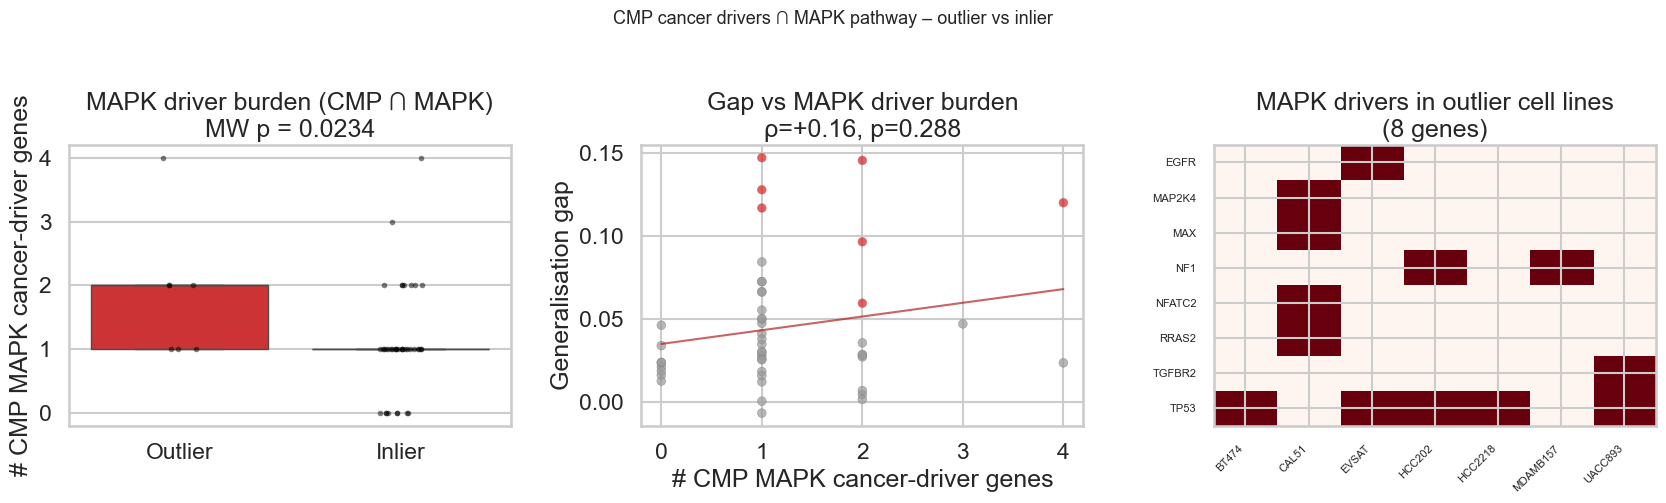

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# CMP cancer drivers ∩ MAPK pathway – outlier vs inlier
# ══════════════════════════════════════════════════════════════════════
# Restrict CMP driver genes to those in the MAPK gene union (from MSigDB).
# Tests: Fisher exact, Mann-Whitney burden, Spearman vs gap.

from scipy.stats import fisher_exact, mannwhitneyu, spearmanr

_MAPK_set = set(_MAPK_GENES)

# Per-cell-line: keep only CMP drivers that are MAPK genes
_mapk_drivers = {}                          # cl → list of MAPK driver genes
for cl in _test_cls:
    hits = sorted(set(_cmp_drivers.get(cl, [])) & _MAPK_set)
    if hits:
        _mapk_drivers[cl] = hits

_drv_mapk = pd.DataFrame({"cell_line": sorted(_test_cls)})
_drv_mapk["is_outlier"] = _drv_mapk["cell_line"].isin(_outlier_in_cbio)
_drv_mapk["n_mapk_drv"] = _drv_mapk["cell_line"].map(
    lambda cl: len(_mapk_drivers.get(cl, [])))
_drv_mapk["has_mapk_drv"] = _drv_mapk["n_mapk_drv"] > 0
_drv_mapk["overall_gap"] = _drv_mapk["cell_line"].map(_overall_gap)
_drv_mapk["mapk_drv_genes"] = _drv_mapk["cell_line"].map(
    lambda cl: ", ".join(_mapk_drivers.get(cl, [])) or "—")

_out_md = _drv_mapk[_drv_mapk["is_outlier"]]
_in_md  = _drv_mapk[~_drv_mapk["is_outlier"]]

# All MAPK driver genes found across test cell lines
_mapk_drv_genes_all = set()
for cl, genes in _mapk_drivers.items():
    _mapk_drv_genes_all.update(genes)

print(f"{'='*70}")
print(f"CMP CANCER DRIVERS ∩ MAPK PATHWAY ({len(_MAPK_set)} MAPK genes)")
print(f"{'='*70}")
print(f"  Unique MAPK driver genes found: {len(_mapk_drv_genes_all)}")
print(f"  Cell lines with ≥1 MAPK driver: "
      f"{_drv_mapk['has_mapk_drv'].sum()}/{len(_drv_mapk)}")

# ── 1. Binary: any MAPK driver ──────────────────────────────────────
_ct = np.array([
    [(oh := _out_md["has_mapk_drv"].sum()), len(_out_md) - oh],
    [(ih := _in_md["has_mapk_drv"].sum()), len(_in_md) - ih],
])
_or_f, _p_f = fisher_exact(_ct)
print(f"\n  Binary (any MAPK driver):")
print(f"    Outliers: {oh}/{len(_out_md)} = {oh/len(_out_md):.0%}")
print(f"    Inliers:  {ih}/{len(_in_md)} = {ih/len(_in_md):.0%}")
print(f"    Fisher exact: OR={_or_f:.2f}, p={_p_f:.4f}")

# ── 2. Burden: MAPK driver count ────────────────────────────────────
_u, _p_u = mannwhitneyu(
    _out_md["n_mapk_drv"], _in_md["n_mapk_drv"], alternative="greater")
print(f"\n  MAPK driver count (burden):")
print(f"    Outliers: median={_out_md['n_mapk_drv'].median():.0f}, "
      f"mean={_out_md['n_mapk_drv'].mean():.1f}")
print(f"    Inliers:  median={_in_md['n_mapk_drv'].median():.0f}, "
      f"mean={_in_md['n_mapk_drv'].mean():.1f}")
print(f"    MW (outlier > inlier): U={_u:.0f}, p={_p_u:.4f}")

# ── 3. Spearman vs gap ──────────────────────────────────────────────
_valid = _drv_mapk.dropna(subset=["overall_gap"])
_rho, _p_rho = spearmanr(_valid["overall_gap"], _valid["n_mapk_drv"])
print(f"\n  Correlation with gap:")
print(f"    Spearman: ρ={_rho:+.3f}, p={_p_rho:.4f}")

# ── 4. Per-cell-line detail for outliers ─────────────────────────────
print(f"\n{'='*70}")
print("OUTLIER CELL LINES – MAPK cancer drivers")
print(f"{'='*70}")
for _, row in _out_md.sort_values("overall_gap", ascending=False).iterrows():
    print(f"  {row['cell_line']:15s} (gap={row['overall_gap']:.4f}, "
          f"n={row['n_mapk_drv']:2d}): {row['mapk_drv_genes']}")

# ── 5. Per-gene detail ───────────────────────────────────────────────
print(f"\n{'='*70}")
print(f"PER-GENE DETAIL – {len(_mapk_drv_genes_all)} MAPK driver genes")
print(f"{'='*70}")
_per_gene = []
for gene in sorted(_mapk_drv_genes_all):
    _cls_with = {cl for cl, gs in _mapk_drivers.items() if gene in gs}
    _out_yes = sorted(_cls_with & _outlier_in_cbio)
    _in_yes  = sorted(_cls_with & _inlier_in_cbio)
    ct = np.array([
        [len(_out_yes), len(_outlier_in_cbio) - len(_out_yes)],
        [len(_in_yes),  len(_inlier_in_cbio) - len(_in_yes)],
    ])
    odds, p = fisher_exact(ct)
    _per_gene.append({
        "gene": gene,
        "n_outlier": len(_out_yes), "n_inlier": len(_in_yes),
        "outlier_cls": ", ".join(_out_yes) or "—",
        "inlier_cls": ", ".join(_in_yes) or "—",
        "odds_ratio": odds, "p_value": p,
    })
    direction = "↑ outlier" if odds > 1 else "↓ inlier" if odds < 1 else "="
    sig = "†" if p < 0.05 else ""
    print(f"  {gene:12s}: out={len(_out_yes)} ({', '.join(_out_yes) or '—':30s}) "
          f"in={len(_in_yes):2d} | OR={odds:.2f}, p={p:.3g} {sig} {direction}")

_per_gene_df = pd.DataFrame(_per_gene).sort_values("p_value")
display(_per_gene_df.round(4))

# ── 6. Visualisation: 1×3 ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

_drv_mapk["Group"] = _drv_mapk["is_outlier"].map({True: "Outlier", False: "Inlier"})

# 6a. Boxplot: MAPK driver count
ax = axes[0]
sns.boxplot(data=_drv_mapk, x="Group", y="n_mapk_drv",
            order=["Outlier", "Inlier"],
            palette={"Outlier": "#e41a1c", "Inlier": "#cccccc"},
            ax=ax, showfliers=False)
sns.stripplot(data=_drv_mapk, x="Group", y="n_mapk_drv",
              order=["Outlier", "Inlier"],
              color="black", size=4, alpha=0.5, ax=ax, jitter=True)
ax.set_ylabel("# CMP MAPK cancer-driver genes")
ax.set_xlabel("")
ax.set_title(f"MAPK driver burden (CMP ∩ MAPK)\nMW p = {_p_u:.3g}")

# 6b. Scatter: MAPK driver count vs gap
ax = axes[1]
ax.scatter(_drv_mapk["n_mapk_drv"], _drv_mapk["overall_gap"],
           s=40, alpha=0.7, edgecolor="grey", linewidth=0.4,
           c=_drv_mapk["is_outlier"].map({True: "#e41a1c", False: "#999999"}))
if _drv_mapk["n_mapk_drv"].max() > _drv_mapk["n_mapk_drv"].min():
    z = np.polyfit(_drv_mapk["n_mapk_drv"], _drv_mapk["overall_gap"], 1)
    xl = np.linspace(_drv_mapk["n_mapk_drv"].min(),
                     _drv_mapk["n_mapk_drv"].max(), 50)
    ax.plot(xl, np.polyval(z, xl), color="firebrick", linewidth=1.5, alpha=0.7)
ax.set_xlabel("# CMP MAPK cancer-driver genes")
ax.set_ylabel("Generalisation gap")
ax.set_title(f"Gap vs MAPK driver burden\nρ={_rho:+.2f}, p={_p_rho:.3g}")

# 6c. Heatmap: MAPK driver genes × outlier cell lines
ax = axes[2]
_outlier_list = sorted(_outlier_in_cbio)
_mapk_drv_sorted = sorted(_mapk_drv_genes_all)
if _mapk_drv_sorted:
    _hm = pd.DataFrame(0, index=_mapk_drv_sorted, columns=_outlier_list)
    for cl in _outlier_list:
        for g in _mapk_drivers.get(cl, []):
            if g in _hm.index:
                _hm.loc[g, cl] = 1
    _hm = _hm.loc[_hm.sum(axis=1) > 0]
    im = ax.imshow(_hm.values, cmap="Reds", aspect="auto", vmin=0, vmax=1)
    ax.set_xticks(range(len(_hm.columns)))
    ax.set_xticklabels([c.replace("c","",1) for c in _hm.columns],
                       rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(_hm.index)))
    ax.set_yticklabels(_hm.index, fontsize=8)
    ax.set_title(f"MAPK drivers in outlier cell lines\n({len(_hm)} genes)")
else:
    ax.text(0.5, 0.5, "No MAPK drivers found", ha="center", va="center",
            transform=ax.transAxes)

fig.suptitle("CMP cancer drivers ∩ MAPK pathway – outlier vs inlier",
             fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

## RF classifier: what distinguishes outlier cell lines?

Use metadata from **cBioPortal** (CCLE mutations), **Cellosaurus** (curated annotations & mutations),
and **Cell Model Passports / Sanger** (cancer driver mutations via intOGen + COSMIC Tier 1)
to build a feature matrix, then train a Random Forest classifier (outlier vs inlier)
and apply Recursive Feature Elimination (RFE) to find the minimal set of predictive features.

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# Step 1 – Build a comprehensive feature matrix for outlier classification
# Sources: cBioPortal (CCLE), Cellosaurus, Cell Model Passports (Sanger)
# Now using consolidated cell_line_annotations module with caching.
# ══════════════════════════════════════════════════════════════════════

from importlib import reload
import cell_line_annotations as cla
reload(cla)

# ── Re-run outlier detection to get fresh variables ──────────────────
_flags_ol, _summary_ol, _mat_ol = detect_heatmap_outliers(
    by_df, model_label=_model_label, context=_context, mode="gap", ref="DMM")
_all_cls = sorted(_mat_ol.index)
_outlier_cls = set(_summary_ol["cell_line"])
_inlier_cls = set(_all_cls) - _outlier_cls
print(f"Cell lines: {len(_all_cls)} total, {len(_outlier_cls)} outliers, "
      f"{len(_inlier_cls)} inliers")

# ── Build feature matrix (with caching) ─────────────────────────────
# Set cache_dir=features_dir to enable disk caching of API results.
# To force a refresh, call: cla.invalidate_cache(features_dir)
_X, _y = cla.build_feature_matrix(
    _all_cls,
    _outlier_cls,
    cache_dir=features_dir,
    file_dir=features_dir,
)

# Also store the raw annotations for downstream analysis cells
_ann = cla.get_all_annotations(_all_cls, cache_dir=features_dir, file_dir=features_dir)
_cbio_df = _ann["cbio_df"]
_cmp_drivers = _ann["cmp_driver_mutations"]
_cl_to_sidm = _ann["cl_to_sidm"]
cello_annot = _ann["cello_annot"]
cello_modality = _ann["cello_modality"]
CMP_BASE = cla.CMP_BASE

display(_X.head(3))

Cell lines: 58 total, 26 outliers, 32 inliers
══════════════════════════════════════════════════════════════════════
Fetching all cell-line annotations …
══════════════════════════════════════════════════════════════════════

[1/4] Cellosaurus …
  [cache hit] Cellosaurus annotations loaded from cache

[2/4] cBioPortal CCLE …
  [cache hit] cBioPortal mutations loaded from cache

[3/4] Cell Model Passports …
  [cache hit] 791 CMP driver genes loaded from cache
  [cache hit] CMP driver mutations loaded from cache

[4/4] Subtypes …
  PAM50: 52 cell lines, LB: 52 cell lines

══════════════════════════════════════════════════════════════════════
All annotations fetched.
══════════════════════════════════════════════════════════════════════
  cBioPortal features: 182 columns
  Cellosaurus features: 12 seq-var + 3 numeric + 15 categorical
  CMP features: 18 columns
  Marcotte features: 4 numeric + 56 categorical

Feature matrix: 58 cell lines × 291 features
Target: 26 outliers, 32 inliers
Feat

,cbio_ABL2,cbio_ACVR2A,cbio_AFDN,cbio_APC,cbio_AR,cbio_ARHGAP35,cbio_ARHGEF10,cbio_ARHGEF12,cbio_ARID1A,cbio_ARID1B,...,marc_subtype_rppa_rppa4,marc_subtype_rppa_rppa8,marc_subtype_rppa_rppa9,marc_subtype_screen_unsupervised_cluster1,marc_subtype_screen_unsupervised_cluster2,marc_subtype_screen_unsupervised_cluster3,marc_subtype_screen_unsupervised_cluster4,marc_subtype_screen_unsupervised_cluster5,marc_subtype_screen_unsupervised_cluster6,marc_subtype_screen_unsupervised_nan
c184A1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
c184B5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
cAU565,0,0,0,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,0


In [ ]:
# ── Show CMP driver gene frequencies and deduplicate with cBioPortal ──

from collections import Counter

_cmp_gene_freq = Counter()
for cl, genes in _cmp_drivers.items():
    for g in set(genes):
        _cmp_gene_freq[g] += 1

if _cmp_gene_freq:
    _cmp_freq_df = pd.DataFrame(
        sorted(_cmp_gene_freq.items(), key=lambda x: -x[1]),
        columns=["gene", "n_cell_lines"]
    )
    print(f"Top 20 CMP cancer driver genes:")
    display(_cmp_freq_df.head(20))
else:
    print("No CMP driver genes found.")

# Remove duplicate information: if a cmp_ column highly correlates with
# a cbio_ column for the same gene, drop the cmp_ version
_cmp_cols = [c for c in _X.columns if c.startswith("cmp_")]
_drop_cmp = []
for cc in _cmp_cols:
    gene = cc.replace("cmp_", "")
    cbio_col = f"cbio_{gene}"
    if cbio_col in _X.columns:
        corr = _X[cc].corr(_X[cbio_col])
        if corr > 0.8:
            _drop_cmp.append(cc)
if _drop_cmp:
    print(f"\nDropping {len(_drop_cmp)} CMP columns redundant with cBioPortal: "
          f"{[c.replace('cmp_', '') for c in _drop_cmp]}")
    _X = _X.drop(columns=_drop_cmp)

# Recompute target (unchanged)
_y = pd.Series(0, index=_all_cls, name="outlier")
_y.loc[_y.index.isin(_outlier_cls)] = 1

print(f"\n{'='*70}")
print(f"FINAL feature matrix: {_X.shape[0]} cell lines × {_X.shape[1]} features")
print(f"Target: {_y.sum()} outliers, {(~_y.astype(bool)).sum()} inliers")
print(f"Feature groups: cBioPortal={len([c for c in _X.columns if c.startswith('cbio_')])},"
      f" Cellosaurus={len([c for c in _X.columns if c.startswith('cello_')])},"
      f" CMP={len([c for c in _X.columns if c.startswith('cmp_')])},"
      f" Marcotte={len([c for c in _X.columns if c.startswith('marc_')])}")
print(f"{'='*70}")

Top 20 CMP cancer driver genes:


,gene,n_cell_lines
0,TP53,33
1,PIK3CA,17
2,PTEN,9
3,NF1,6
4,CDH1,6
5,BRCA2,5
6,ARID1A,5
7,HLA-A,5
8,BIRC6,4
9,BRCA1,4



Dropping 6 CMP columns redundant with cBioPortal: ['TP53', 'PIK3CA', 'RHOA', 'PTEN', 'BRCA1', 'NIPBL']

FINAL feature matrix: 58 cell lines × 285 features
Target: 26 outliers, 32 inliers
Feature groups: cBioPortal=182, Cellosaurus=31, CMP=12, Marcotte=60


Running cross-validated RF classifier (5-fold × 10 repeats) …

Baseline RF (all 285 features):
  ROC-AUC:             0.328 ± 0.156
  Balanced accuracy:   0.370 ± 0.136
  Chance level:        AUC=0.500, BA=0.500

Iterative RFE (reduce_factor=0.9, stop at peak BA) …

Baseline RF (all 285 features):
  ROC-AUC:             0.328 ± 0.156
  Balanced accuracy:   0.370 ± 0.136
  Chance level:        AUC=0.500, BA=0.500

Iterative RFE (reduce_factor=0.9, stop at peak BA) …
  → 285 features  (BA=0.403)
  → 285 features  (BA=0.403)
  → 257 features  (BA=0.407)
  → 257 features  (BA=0.407)
  → 232 features  (BA=0.440)
  → 232 features  (BA=0.440)
  → 209 features  (BA=0.481)
  → 209 features  (BA=0.481)
  → 189 features  (BA=0.486)
  → 189 features  (BA=0.486)
  → 171 features  (BA=0.486)
  → 171 features  (BA=0.486)
  → 154 features  (BA=0.485)
  → 154 features  (BA=0.485)
  → 139 features  (BA=0.497)
  → 139 features  (BA=0.497)
  → 126 features  (BA=0.479)
  → 126 features  (BA=0.479)
  → 114 

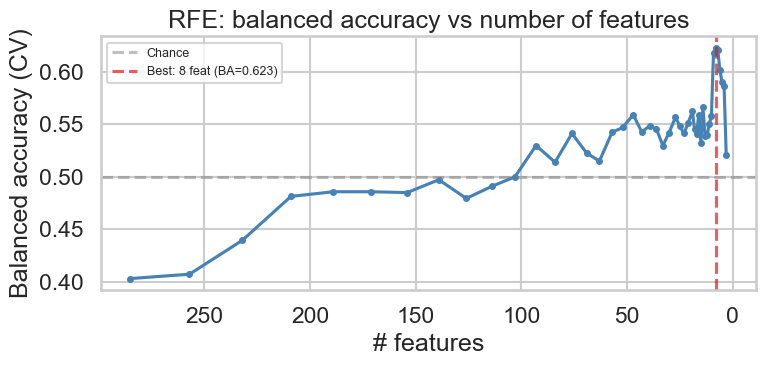


Cell-line summary (sorted by gap, with Marcotte subtypes)


,is_outlier,n_mapk_muts,n_total_muts,overall_gap,cbio_TMB,cello_doubling_time,marc_subtype_rppa_rppa8,cello_n_crossrefs,cbio_TPR,marc_subtype_curtis_Intclust4,cbio_PIK3CA,cbio_CIC
cell_line,,,,,,,,,,,,
cHCC2218,True,8,359,0.146975,359,120.00,0,67,0,0,0,1
cEVSAT,True,10,507,0.145341,507,25.00,0,50,0,0,0,0
cBT474,True,26,932,0.127679,932,84.00,0,178,0,0,1,1
cCAL51,True,21,779,0.119880,779,24.00,0,57,0,1,1,0
cMDAMB157,True,12,432,0.116686,432,67.20,0,96,0,0,0,0
cUACC893,True,7,382,0.096371,382,120.00,0,63,0,0,1,0
cDU4475,False,2,253,0.084235,253,69.60,0,65,0,0,0,0
cMDAMB436,False,8,373,0.072376,373,89.31,0,114,0,0,0,0
cT47D,False,1,149,0.072334,149,38.40,1,213,0,0,1,0


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# Step 2 – RF classifier + iterative RFE (select_features.py pattern)
# ══════════════════════════════════════════════════════════════════════
# Reuses the multiplicative-reduction RFE strategy from select_features.py:
#   fit RF → rank by importance → keep top reduce_factor fraction → repeat
# Adapted: RandomForestClassifier (not Regressor), balanced_accuracy metric,
# and n_jobs=1 to avoid loky/semlock issues on macOS.
# **RFE now stops at the feature set that achieves the highest BA.**
# No StandardScaler – RF is scale-invariant.

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.inspection import permutation_importance

def _get_feature_importances(model, X, y, method="tree"):
    """Return feature importances from a fitted RF model."""
    if method == "tree":
        return model.feature_importances_
    elif method == "permute":
        result = permutation_importance(
            model, X, y, n_repeats=10, random_state=42, n_jobs=1)
        return result.importances_mean
    else:
        raise ValueError(f"Unknown method: {method}")

# ── 2A. Baseline RF with cross-validation ────────────────────────────
_rng = 42
_cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=_rng)

_base_rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=4,
    min_samples_leaf=3,
    class_weight="balanced",
    random_state=_rng,
)

print("Running cross-validated RF classifier (5-fold × 10 repeats) …")
_X_arr = _X.values.astype(float)
_y_arr = _y.values

_auc_scores = cross_val_score(_base_rf, _X_arr, _y_arr, cv=_cv,
                               scoring="roc_auc")
_ba_scores = cross_val_score(_base_rf, _X_arr, _y_arr, cv=_cv,
                              scoring="balanced_accuracy")

print(f"\nBaseline RF (all {_X.shape[1]} features):")
print(f"  ROC-AUC:             {_auc_scores.mean():.3f} ± {_auc_scores.std():.3f}")
print(f"  Balanced accuracy:   {_ba_scores.mean():.3f} ± {_ba_scores.std():.3f}")
print(f"  Chance level:        AUC=0.500, BA=0.500")

# ── 2B. Iterative RFE (select_features.py pattern) ──────────────────
# Multiplicative reduction: keep top 80% features each round.
# **Stop at the step with highest BA (early-stop at peak).**
_reduce_factor = 0.90
_min_features = 3        # absolute lower bound
_method = "permute"      # permutation importance when ≤500 features
_rfe_input = _X.copy()

_rfe_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=4,
    min_samples_leaf=3,
    max_features=_reduce_factor,
    class_weight="balanced",
    random_state=_rng,
)

_rfe_history = []          # (n_features, balanced_acc, feature_set)
_rfe_snapshots = {}        # n_features → DataFrame snapshot

print(f"\nIterative RFE (reduce_factor={_reduce_factor}, stop at peak BA) …")
while _rfe_input.shape[1] >= _min_features:
    _rfe_model.fit(_rfe_input.values, _y_arr)

    # Cross-validated balanced accuracy at this feature set size
    _step_ba = cross_val_score(
        _rfe_model, _rfe_input.values, _y_arr,
        cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=_rng),
        scoring="balanced_accuracy",
    ).mean()
    _rfe_history.append((_rfe_input.shape[1], _step_ba, list(_rfe_input.columns)))
    _rfe_snapshots[_rfe_input.shape[1]] = _rfe_input.copy()
    print(f"  → {_rfe_input.shape[1]:>3} features  (BA={_step_ba:.3f})")

    # Stop if we've reached the minimum
    _n_next = int(np.ceil(_rfe_input.shape[1] * _reduce_factor))
    if _n_next == _rfe_input.shape[1]:
        _n_next -= 1
    if _n_next < _min_features:
        break

    # Feature importances (Gini for many features, permutation for ≤500)
    _imp_method = _method if _rfe_input.shape[1] <= 500 else "tree"
    _importances = _get_feature_importances(
        _rfe_model, _rfe_input.values, _y_arr, method=_imp_method,
    )
    _top_idx = np.argsort(_importances)[::-1][:_n_next]
    _rfe_input = _rfe_input.iloc[:, _top_idx]

# ── Select best step (highest BA) ───────────────────────────────────
_best_step = max(_rfe_history, key=lambda x: x[1])
_best_n, _best_ba, _best_features = _best_step
_selected = _best_features

print(f"\n{'='*70}")
print(f"Best RFE step: {_best_n} features  (BA={_best_ba:.3f})")
print(f"{'='*70}")

# Rank features by importance at the best step
_best_X = _rfe_snapshots[_best_n]
_rfe_model.fit(_best_X.values, _y_arr)
_best_imp = _get_feature_importances(
    _rfe_model, _best_X.values, _y_arr, method=_method,
)
_imp_order = np.argsort(_best_imp)[::-1]
print(f"\nSelected {_best_n} features (ranked by permutation importance):")
for rank, idx in enumerate(_imp_order):
    feat = _selected[idx]
    src = feat.split("_")[0]
    print(f"  {rank+1:2d}. {feat:40s}  [imp={_best_imp[idx]:.4f}, source={src}]")

# ── 2C. Full feature importance ranking from the complete model ──────
_base_rf.fit(_X_arr, _y_arr)
_full_imp = pd.Series(_base_rf.feature_importances_, index=_X.columns
                       ).sort_values(ascending=False)

print(f"\nTop 20 feature importances (Gini, full model):")
for i, (feat, val) in enumerate(_full_imp.head(20).items()):
    src = feat.split("_")[0]
    print(f"  {i+1:2d}. {feat:40s}  {val:.4f}  [{src}]")

# ── 2D. Performance comparison: all features vs best-RFE ────────────
_X_sel = _best_X.values.astype(float)
_auc_sel = cross_val_score(
    RandomForestClassifier(
        n_estimators=500, max_depth=4, min_samples_leaf=3,
        class_weight="balanced", random_state=_rng,
    ),
    _X_sel, _y_arr, cv=_cv, scoring="roc_auc",
)
_ba_sel = cross_val_score(
    RandomForestClassifier(
        n_estimators=500, max_depth=4, min_samples_leaf=3,
        class_weight="balanced", random_state=_rng,
    ),
    _X_sel, _y_arr, cv=_cv, scoring="balanced_accuracy",
)

print(f"\n{'='*70}")
print(f"RF with {_best_n} RFE-selected features (best BA step):")
print(f"  ROC-AUC:           {_auc_sel.mean():.3f} ± {_auc_sel.std():.3f}")
print(f"  Balanced accuracy: {_ba_sel.mean():.3f} ± {_ba_sel.std():.3f}")
print(f"\nBaseline RF (all {_X.shape[1]} features) for comparison:")
print(f"  ROC-AUC:           {_auc_scores.mean():.3f} ± {_auc_scores.std():.3f}")
print(f"  Balanced accuracy: {_ba_scores.mean():.3f} ± {_ba_scores.std():.3f}")
print(f"{'='*70}")

# ── 2E. RFE curve: BA vs # features ─────────────────────────────────
_rfe_df = pd.DataFrame(_rfe_history, columns=["n_features", "BA", "features"])
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(_rfe_df["n_features"], _rfe_df["BA"], "o-", color="steelblue", markersize=4)
ax.axhline(0.5, color="grey", linestyle="--", alpha=0.5, label="Chance")
ax.axvline(_best_n, color="#e41a1c", linestyle="--", alpha=0.7,
           label=f"Best: {_best_n} feat (BA={_best_ba:.3f})")
ax.set_xlabel("# features")
ax.set_ylabel("Balanced accuracy (CV)")
ax.set_title("RFE: balanced accuracy vs number of features")
ax.legend(fontsize=9)
ax.invert_xaxis()
fig.tight_layout()
plt.show()

# ── 2F. Cell-line summary with Marcotte metadata ────────────────────
import cell_line_annotations as cla
_marcotte = cla.load_marcotte_subtypes(_all_cls)

_cl_summary = _analysis[["cell_line", "is_outlier", "n_mapk_muts",
                          "n_total_muts", "overall_gap"]].copy()
_cl_summary = _cl_summary.set_index("cell_line")

# Add selected-feature values
for feat in _selected:
    if feat in _X.columns:
        _cl_summary[feat] = _X[feat]

_cl_summary = _cl_summary.sort_values("overall_gap", ascending=False)

print(f"\n{'='*70}")
print(f"Cell-line summary (sorted by gap, with Marcotte subtypes)")
print(f"{'='*70}")
display(_cl_summary)

## Residual heatmaps (all split)

Clustered heatmap of per-cell-line RMSE from the `all_plus_missingtx` split
(trained on all cell lines). Rows = cell lines, columns = (condition, observable).
Shows which cell line × observable combinations are hardest to fit.

In [ ]:
# RMSE heatmaps for DMM and best regressor
for model_label in models:
    ctx_list = sorted(all_dfs[model_label]["context"].dropna().unique())
    for context in ctx_list:
        # DMM heatmap
        print(f"\n{'='*60}")
        print(f"Model: {model_label}, Context: {context}, Ref: DMM")
        print(f"{'='*60}")
        plot_heatmap(all_df, model_label, context, ANNOTATION_SPECS, mode="rmse", ref="DMM")
        plt.show()

        # Best regressor heatmap
        br = best_reg[(best_reg["model_label"] == model_label) & (best_reg["context"] == context)]
        if not br.empty:
            best_ref_name = br.iloc[0]["best_ref"]
            print(f"\n{'='*60}")
            print(f"Model: {model_label}, Context: {context}, Ref: {best_ref_name}")
            print(f"{'='*60}")
            plot_heatmap(all_df, model_label, context, ANNOTATION_SPECS, mode="rmse", ref=best_ref_name)
            plt.show()

In [ ]:
# --- Per-observable gap correlations ----------------------------------------
# Compute gap per cell_line × observable (averaged over conditions)
by_obs = by_df[by_df["ref"] == "DMM"].copy()
agg_obs = (
    by_obs.groupby(["cell_line", "model_label", "context", "dataset", "observable"],
                   as_index=False)
    .agg(mean_rmse=("rmse", "mean"))
)
pivot_obs = agg_obs.pivot_table(
    index=["cell_line", "model_label", "context", "observable"],
    columns="dataset", values="mean_rmse",
).reset_index()
pivot_obs = pivot_obs.rename(columns={"train": "rmse_train", "val": "rmse_val"})
pivot_obs = pivot_obs.dropna(subset=["rmse_train", "rmse_val"])
pivot_obs["gap"] = pivot_obs["rmse_val"] - pivot_obs["rmse_train"]

observables = sorted(pivot_obs["observable"].unique())
obs_labels = {o: o.replace("_obs", "").replace("_", " ") for o in observables}
dtype_colors = {"cytof": "#1b9e77", "proteomics": "#d95f02", "transcriptomics": "#7570b3"}

print(f"Observables: {observables}")
print(f"pivot_obs shape: {pivot_obs.shape}")

# Report number of FDR-significant markers per observable × data type
for dtype, n_hvg in [("cytof", None), ("proteomics", 5000), ("transcriptomics", 5000)]:
    md = load_all_marker_data(dtype)
    print(f"\n{dtype}:")
    for obs in observables:
        gap_obs = pivot_obs[pivot_obs["observable"] == obs].set_index("cell_line")["gap"]
        corr_obs = correlate_gap_vs_markers(gap_obs, md, dtype, n_hvg=n_hvg)
        n_sig = corr_obs["significant"].sum()
        best = corr_obs.iloc[0]
        print(f"  {obs}: {n_sig} FDR-significant / {len(corr_obs)} tested  "
              f"(best: {best['marker']}, ρ={best['rho']:+.3f}, q={best['qval']:.2e})")

Observables: ['pERBB2_Y1248_obs', 'pERK_Y204_obs', 'pMEK_S222_obs', 'pRPS6KA1_S380_obs']
pivot_obs shape: (218, 7)

cytof:
  pERBB2_Y1248_obs: 0 FDR-significant / 36 tested  (best: p.MKK3.MKK6, ρ=+0.375, q=3.47e-01)
  pERK_Y204_obs: 0 FDR-significant / 35 tested  (best: p.STAT1, ρ=+0.256, q=8.45e-01)
  pMEK_S222_obs: 0 FDR-significant / 35 tested  (best: p.STAT1, ρ=+0.241, q=8.44e-01)
  pRPS6KA1_S380_obs: 0 FDR-significant / 35 tested  (best: p.p90RSK, ρ=-0.311, q=3.21e-01)

proteomics:

proteomics:
  pERBB2_Y1248_obs: 0 FDR-significant / 1625 tested  (best: PDIA3, ρ=+0.521, q=4.71e-01)
  pERBB2_Y1248_obs: 0 FDR-significant / 1625 tested  (best: PDIA3, ρ=+0.521, q=4.71e-01)
  pERK_Y204_obs: 0 FDR-significant / 1499 tested  (best: KIF23, ρ=-0.405, q=9.97e-01)
  pERK_Y204_obs: 0 FDR-significant / 1499 tested  (best: KIF23, ρ=-0.405, q=9.97e-01)
  pMEK_S222_obs: 0 FDR-significant / 1499 tested  (best: RGS10, ρ=-0.427, q=9.99e-01)
  pMEK_S222_obs: 0 FDR-significant / 1499 tested  (best: RG

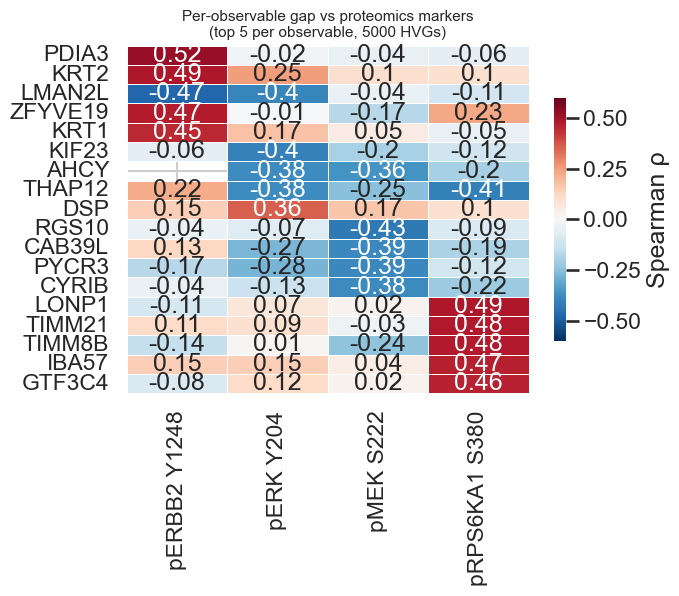

* q<0.05  ** q<0.01  *** q<0.001 (BH FDR-corrected)



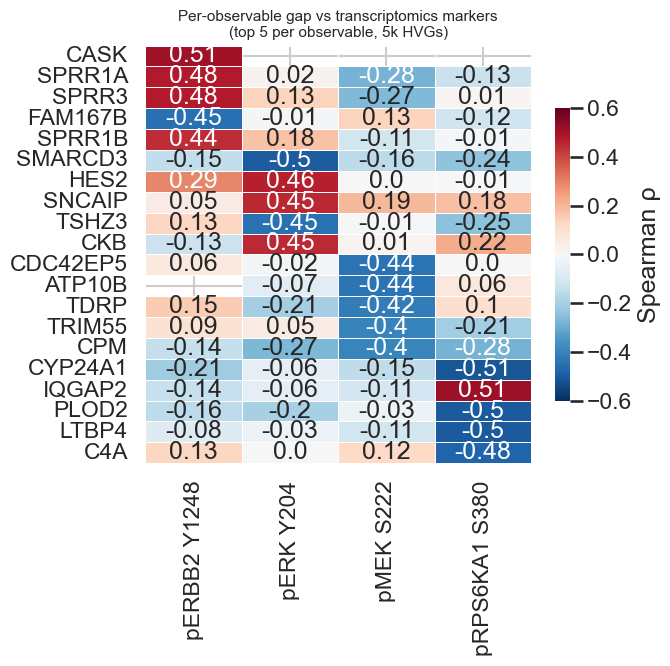

* q<0.05  ** q<0.01  *** q<0.001 (BH FDR-corrected)



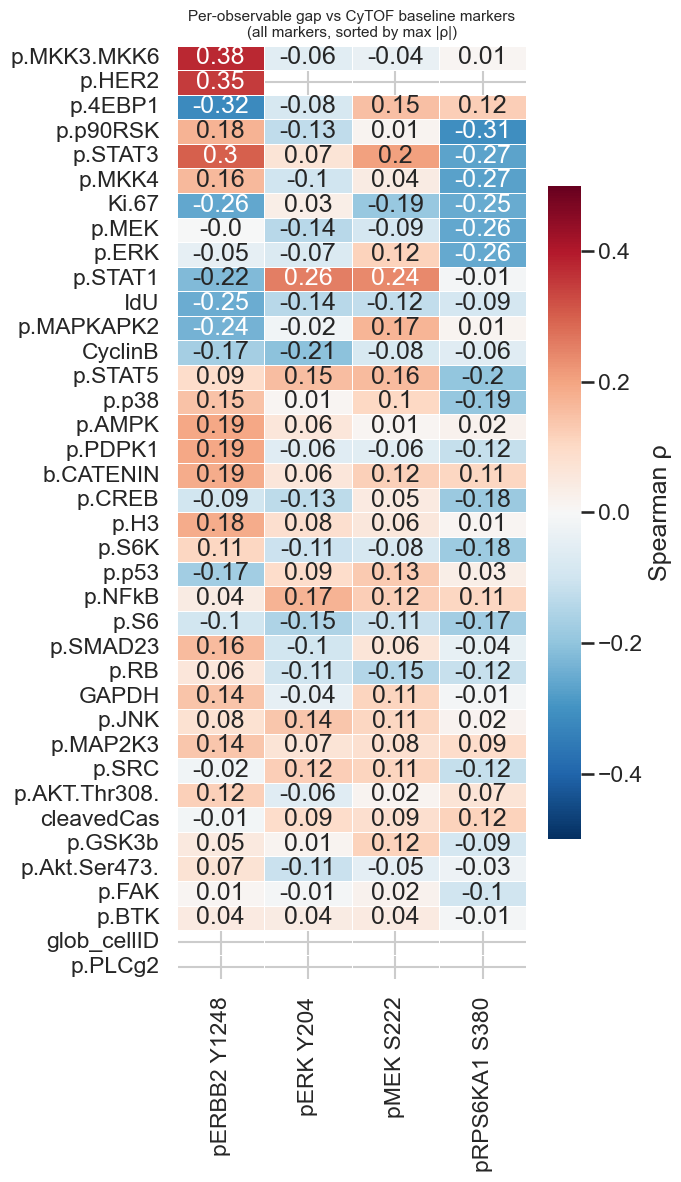

* q<0.05  ** q<0.01  *** q<0.001 (BH FDR-corrected)



In [ ]:
# --- Correlation heatmaps: per-observable gap vs markers (all data types) ---
HEATMAP_CONFIGS = [
    dict(data_type="proteomics",      n_hvg=5000, n_show=5, sort_by_abs_rho=False,
         save_name="gap_vs_proteomics_per_obs_heatmap.pdf"),
    dict(data_type="transcriptomics", n_hvg=5000, n_show=5, sort_by_abs_rho=False,
         save_name="gap_vs_transcriptomics_per_obs_heatmap.pdf",
         title="Per-observable gap vs transcriptomics markers\n(top 5 per observable, 5k HVGs)"),
    dict(data_type="cytof",           n_hvg=None, show_all_markers=True,
         sort_by_abs_rho=True, vmin=-0.5, vmax=0.5, row_height=0.32,
         save_name="gap_vs_cytof_per_obs_heatmap.pdf",
         title="Per-observable gap vs CyTOF baseline markers\n(all markers, sorted by max |ρ|)"),
]

for cfg in HEATMAP_CONFIGS:
    save_name = cfg.pop("save_name")
    save_path = Path(_project_root) / "figures_paper" / save_name
    rho_df, qval_df, fig = marker_obs_correlation_heatmap(
        pivot_obs, save_path=save_path, **cfg,
    )
    plt.show()
    print("* q<0.05  ** q<0.01  *** q<0.001 (BH FDR-corrected)\n")

## Shell-restricted marker–gap / residual correlations

For each observable, restrict markers to the **per-observable gene neighbourhood
shell** from four methods (STRING, MSigDB, OmniPath Interactions, OmniPath Complexes)
around the corresponding seed gene(s):

| Observable | Seed gene(s) | Notes |
|------------|-------------|-------|
| pERBB2_Y1248 | ERBB2 | |
| pERK_Y204 | MAPK1, MAPK3 | ERK2, ERK1 |
| pMEK_S222 | MAP2K1, MAP2K2 | MEK1, MEK2 |
| pRPS6KA1_S380 | RPS6KA1, RPS6KA2, RPS6KA3, RPS6KA6 | All p90RSK isoforms (RSK1–4) |

Two metrics are correlated with markers:
- **Generalisation gap** = val RMSE − train RMSE (from LOOCV)
- **Residual RMSE** = per-cell-line RMSE from the all-split (trained on all cell lines)

BH FDR correction is applied **per observable** at two scopes:
1. **Shell 1 only** (seeds + direct neighbours)
2. **Shell 1 + Shell 2** (full two-hop neighbourhood)

Only statistically significant hits (q < 0.05) are reported.

In [ ]:
# --- Fetch gene neighbourhood shells for STRING + OP Interactions × observable ---
import importlib
import gene_shells as _gs
importlib.reload(_gs)
from gene_shells import get_shells, load_msigdb_gmt, ShellResult, METHODS

MSIGDB_PATH = Path(_project_root) / "data" / "msigdb_c2cp_2025.1.Hs.json"
gmt_all = load_msigdb_gmt(MSIGDB_PATH)

# Observable → seed genes (with _obs suffix to match observable column names)
OBS_TO_SEEDS = {
    "pERBB2_Y1248_obs": ["ERBB2"],
    "pERK_Y204_obs":    ["MAPK1", "MAPK3"],
    "pMEK_S222_obs":    ["MAP2K1", "MAP2K2"],
    "pRPS6KA1_S380_obs":["RPS6KA1", "RPS6KA2", "RPS6KA3", "RPS6KA6"],
}

METHOD_CONFIGS = {
    "STRING (≥900)":          dict(method="string", score=900),
    "OmniPath Interactions":  dict(method="omnipath_interactions"),
}

# Fetch shells: shell_results[obs][method_label] = ShellResult
shell_results: dict[str, dict[str, ShellResult]] = {}
for obs, seeds in OBS_TO_SEEDS.items():
    shell_results[obs] = {}
    for label, kw in METHOD_CONFIGS.items():
        res = get_shells(seeds, **kw)
        shell_results[obs][label] = res
        s = res.summary()
        print(f"  {obs:20s} | {label:25s} | "
              f"{s['n_seeds']} seeds + {s['n_shell1']:>5,} S1 + "
              f"{s['n_shell2']:>5,} S2 = {s['n_all']:>6,} total")

print(f"\nDone: {len(shell_results)} observables × {len(METHOD_CONFIGS)} methods")

  pERBB2_Y1248_obs     | STRING (≥900)             | 1 seeds +    66 S1 + 1,000 S2 =  1,067 total
  pERBB2_Y1248_obs     | OmniPath Interactions     | 1 seeds +   113 S1 + 1,986 S2 =  2,100 total
  pERK_Y204_obs        | STRING (≥900)             | 2 seeds +   157 S1 + 1,000 S2 =  1,159 total
  pERK_Y204_obs        | OmniPath Interactions     | 2 seeds +   368 S1 + 3,381 S2 =  3,751 total
  pERK_Y204_obs        | STRING (≥900)             | 2 seeds +   157 S1 + 1,000 S2 =  1,159 total
  pERK_Y204_obs        | OmniPath Interactions     | 2 seeds +   368 S1 + 3,381 S2 =  3,751 total
  pMEK_S222_obs        | STRING (≥900)             | 2 seeds +    43 S1 +   776 S2 =    821 total
  pMEK_S222_obs        | OmniPath Interactions     | 2 seeds +   134 S1 + 2,362 S2 =  2,498 total
  pMEK_S222_obs        | STRING (≥900)             | 2 seeds +    43 S1 +   776 S2 =    821 total
  pMEK_S222_obs        | OmniPath Interactions     | 2 seeds +   134 S1 + 2,362 S2 =  2,498 total
  pRPS6KA1_S380_obs 

In [ ]:
# --- Import shared shell-restricted correlation function ----------------------
import importlib
import figures_paper.shell_correlations as _sc
importlib.reload(_sc)
from figures_paper.shell_correlations import shell_restricted_correlations

shell_restricted_correlations imported from figures_paper.shell_correlations


In [ ]:
# --- Run per-job shell-restricted correlations and collect significant hits ---
# Computes per-method AND union (all methods) correlations, all in sig_df.
# Uses seeds + shell1 (seed_and_shell1) for each method.
prot_all = load_all_marker_data("proteomics")
tx_all   = load_all_marker_data("transcriptomics")

# Drop markers missing in >30% of cell lines
MAX_MISSING_FRAC = 0.3
for label, md in [("proteomics", prot_all), ("transcriptomics", tx_all)]:
    n_before = md.shape[1]
    drop_mask = md.isna().mean(axis=0) > MAX_MISSING_FRAC
    dropped = drop_mask.sum()
    md.drop(columns=md.columns[drop_mask], inplace=True)
    print(f"{label}: dropped {dropped}/{n_before} markers with >{MAX_MISSING_FRAC:.0%} missing "
          f"→ {md.shape[1]} remaining")

N_HVG = 8000           # HVG pre-filter for transcriptomics
UNION_LABEL = "Union (all)"

all_sig_rows = []

for obs in observables:
    # Collect seeds across all methods for this observable
    all_seeds = set()
    for ml in METHOD_CONFIGS:
        sr = shell_results[obs][ml]
        all_seeds |= set(sr.seeds)

    gap_jobs  = {j: gap_per_job[j][obs]  for j in gap_per_job  if obs in gap_per_job[j]}
    rmse_jobs = {j: rmse_per_job[j][obs] for j in rmse_per_job if obs in rmse_per_job[j]}

    for metric_label, metric_jobs in [("gap", gap_jobs), ("residual_rmse", rmse_jobs)]:
        for dtype_label, md_full, n_hvg in [
            ("proteomics", prot_all, None),
            ("transcriptomics", tx_all, N_HVG),
        ]:
            # --- Per-method correlations (seeds + S1) ---
            for method_label in METHOD_CONFIGS:
                sr = shell_results[obs][method_label]
                df = shell_restricted_correlations(
                    metric_jobs, md_full,
                    shell_genes=set(sr.seed_and_shell1),
                    seeds_set=set(sr.seeds),
                    data_type_label=dtype_label, n_hvg=n_hvg,
                )
                if df.empty:
                    continue
                sig = df[df["significant"]].copy()
                if not sig.empty:
                    sig["observable"] = obs
                    sig["metric"] = metric_label
                    sig["shell_method"] = method_label
                    all_sig_rows.append(sig)

            # --- Union correlations (all methods' genes pooled) ---
            union_genes = set()
            for ml in METHOD_CONFIGS:
                union_genes |= set(shell_results[obs][ml].seed_and_shell1)

            df_u = shell_restricted_correlations(
                metric_jobs, md_full,
                shell_genes=union_genes,
                seeds_set=all_seeds,
                data_type_label=dtype_label, n_hvg=n_hvg,
            )
            if not df_u.empty:
                sig_u = df_u[df_u["significant"]].copy()
                if not sig_u.empty:
                    sig_u["observable"] = obs
                    sig_u["metric"] = metric_label
                    sig_u["shell_method"] = UNION_LABEL
                    all_sig_rows.append(sig_u)

sig_df = pd.concat(all_sig_rows, ignore_index=True) if all_sig_rows else pd.DataFrame()
print(f"\nTotal significant hits: {len(sig_df)}")
if len(sig_df) > 0:
    print(f"\nBreakdown by shell method × metric × data type:")
    print(sig_df.groupby(["shell_method", "metric", "data_type"]).size()
          .unstack(fill_value=0).to_string())
    n_seed_hits = (sig_df["shell"] == "seed").sum()
    n_s1_hits = (sig_df["shell"] == "S1").sum()
    print(f"\nOf these: {n_seed_hits} seeds, {n_s1_hits} S1")

proteomics: dropped 1700/7877 markers with >30% missing → 6177 remaining
transcriptomics: dropped 0/16562 markers with >30% missing → 16562 remaining

Total significant hits: 5

Breakdown by shell method × metric × data type:
data_type                            proteomics  transcriptomics
shell_method          metric                                    
OmniPath Interactions residual_rmse           0                1
STRING (≥900)         residual_rmse           3                0
Union (all)           residual_rmse           0                1

Of these: 1 seeds, 4 S1


In [ ]:
# --- Display significant hits table -------------------------------------------
if len(sig_df) > 0:
    display_cols = ["observable", "shell_method", "metric", "data_type",
                    "marker", "shell", "rho", "rho_std", "pval", "qval",
                    "n_tested", "n_jobs"]
    styled = (
        sig_df[display_cols]
        .sort_values(["observable", "shell_method", "metric", "qval"])
        .reset_index(drop=True)
        .style.format({
            "rho": "{:+.3f}",
            "rho_std": "{:.3f}",
            "pval": "{:.2e}",
            "qval": "{:.2e}",
        })
        .background_gradient(subset=["rho"], cmap="RdBu_r", vmin=-0.6, vmax=0.6)
    )
    display(styled)
else:
    print("No statistically significant hits found.")

,observable,shell_method,metric,data_type,marker,shell,rho,rho_std,pval,qval,n_tested,n_jobs
0,pMEK_S222_obs,OmniPath Interactions,residual_rmse,transcriptomics,ERBB3,S1,-0.454,0.044,3.51e-04,2.21e-02,63,10
1,pMEK_S222_obs,STRING (≥900),residual_rmse,proteomics,MAP2K1,seed,+0.407,0.039,1.12e-03,2.35e-02,33,10
2,pMEK_S222_obs,STRING (≥900),residual_rmse,proteomics,PAK4,S1,-0.356,0.052,5.41e-03,3.79e-02,33,10
3,pMEK_S222_obs,STRING (≥900),residual_rmse,proteomics,ARAF,S1,-0.352,0.052,5.40e-03,3.79e-02,33,10
4,pMEK_S222_obs,Union (all),residual_rmse,transcriptomics,ERBB3,S1,-0.454,0.044,3.51e-04,2.35e-02,67,10


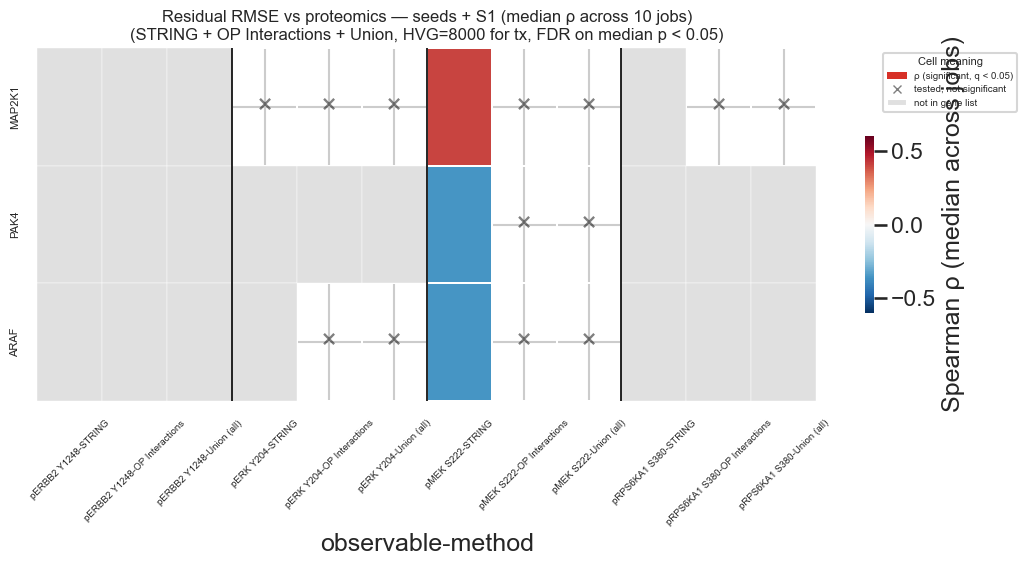

  3 markers shown


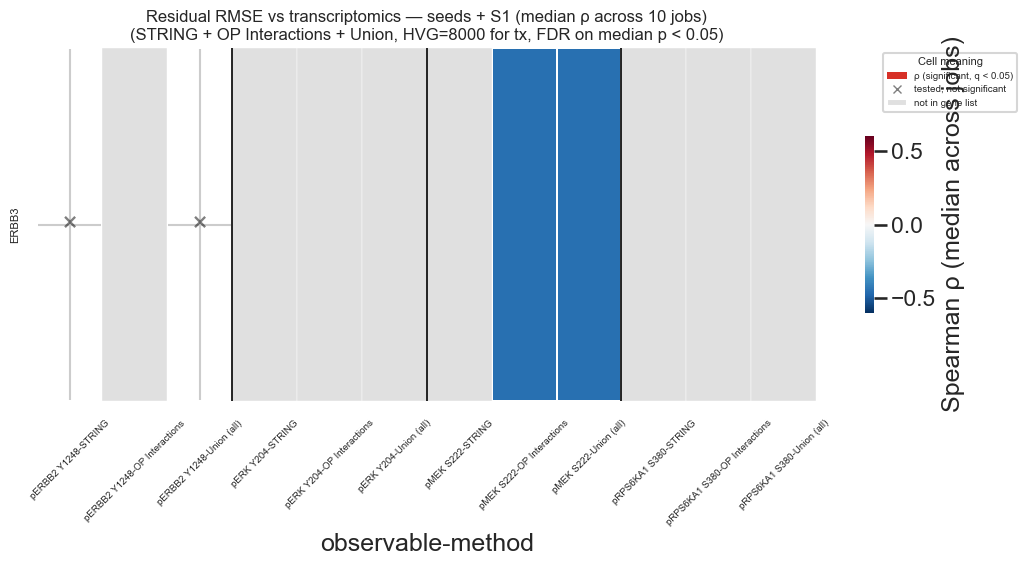

  1 markers shown


In [ ]:
# --- Heatmap: seeds + S1, STRING + OP Interactions + Union column --------
# Everything comes from sig_df (including union rows).
# Three visual states per cell:
#   • Coloured (ρ)       — marker in gene list, tested, and FDR-significant (q < 0.05)
#   • Coloured + "×"     — marker in gene list, tested, but NOT significant
#   • Solid grey (#e0e0e0) — marker NOT in that method's gene list for this observable
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D

ALPHA = 0.05

if len(sig_df) > 0:
    short_obs = {o: o.replace("_obs", "").replace("_", " ") for o in observables}
    method_labels_list = list(METHOD_CONFIGS.keys()) + [UNION_LABEL]
    short_method = {m: m.split("(")[0].strip() if "(" in m else m.replace("OmniPath ", "OP ")
                    for m in method_labels_list}
    short_method[UNION_LABEL] = UNION_LABEL
    n_methods = len(method_labels_list)

    # Build ρ lookup: (marker, obs, method, metric, dtype) → ρ
    rho_lookup = {}
    for _, row in sig_df.iterrows():
        rho_lookup[(row["marker"], row["observable"], row["shell_method"],
                    row["metric"], row["data_type"])] = row["rho"]

    # Build scope: which markers are in each method's gene list per obs
    # (seeds + S1 = seed_and_shell1)
    scope_genes = {}  # (obs, method) → set of genes
    for obs in observables:
        union_scope = set()
        for ml in METHOD_CONFIGS:
            sr = shell_results[obs][ml]
            sg = set(sr.seed_and_shell1)
            scope_genes[(obs, ml)] = sg
            union_scope |= sg
        scope_genes[(obs, UNION_LABEL)] = union_scope

    for metric_label in ["gap", "residual_rmse"]:
        for dtype_label in ["proteomics", "transcriptomics"]:
            sub = sig_df[(sig_df["metric"] == metric_label) &
                         (sig_df["data_type"] == dtype_label)]
            if sub.empty:
                continue

            sig_markers = sorted(sub["marker"].unique())

            # HVG-filtered columns (for "in gene list" check)
            seeds_all = set()
            for obs in observables:
                for ml in METHOD_CONFIGS:
                    seeds_all |= set(shell_results[obs][ml].seeds)
            md_raw = prot_all if dtype_label == "proteomics" else tx_all
            nhvg = N_HVG if dtype_label == "transcriptomics" else None
            md_cols = set(_sc._hvg_filter(md_raw, seeds_all, nhvg).columns)

            # Assemble ρ / in-shell matrices
            col_tuples, rho_data, in_shell = [], {}, {}

            for obs in observables:
                for ml in method_labels_list:
                    ck = (obs, ml)
                    col_tuples.append(ck)
                    rho_data[ck], in_shell[ck] = {}, {}
                    for m in sig_markers:
                        if m in scope_genes[(obs, ml)] and m in md_cols:
                            in_shell[ck][m] = True
                            rho_data[ck][m] = rho_lookup.get(
                                (m, obs, ml, metric_label, dtype_label), np.nan)
                        else:
                            in_shell[ck][m] = False
                            rho_data[ck][m] = np.nan

            rho_mat = pd.DataFrame(rho_data, index=sig_markers)
            in_shell_mat = pd.DataFrame(in_shell, index=sig_markers)

            display_cols = [(short_obs[o], short_method[ml]) for o, ml in col_tuples]
            rho_display = rho_mat.copy()
            rho_display.columns = pd.MultiIndex.from_tuples(display_cols,
                                                            names=["observable", "method"])
            in_shell_display = in_shell_mat.copy()
            in_shell_display.columns = rho_display.columns

            # Sort rows by max |ρ|
            max_abs = rho_display.abs().max(axis=1).sort_values(ascending=False)
            rho_display = rho_display.loc[max_abs.index]
            in_shell_display = in_shell_display.loc[max_abs.index]

            # Significance lookup from sig_df
            sig_lookup = set()
            for _, row in sub.iterrows():
                sig_lookup.add((row["marker"], short_obs[row["observable"]],
                                short_method[row["shell_method"]]))

            # --- Plot ---
            n_markers = len(rho_display)
            n_cols = len(col_tuples)
            metric_nice = "Generalisation gap" if metric_label == "gap" else "Residual RMSE"

            fig, ax = plt.subplots(figsize=(max(10, n_cols * 0.9),
                                            max(6, n_markers * 0.35)))
            sns.heatmap(rho_display, cmap="RdBu_r", center=0, vmin=-0.6, vmax=0.6,
                        linewidths=0.3, linecolor="white", mask=~in_shell_display,
                        cbar_kws={"label": "Spearman ρ (median across jobs)",
                                  "shrink": 0.5}, ax=ax)

            for i in range(n_markers):
                mk = rho_display.index[i]
                for j in range(n_cols):
                    ol, ml = rho_display.columns[j]
                    if not in_shell_display.iloc[i, j]:
                        ax.add_patch(Rectangle((j, i), 1, 1, fill=True,
                                     facecolor="#e0e0e0", edgecolor="white", linewidth=0.3))
                    elif (mk, ol, ml) not in sig_lookup:
                        ax.text(j + 0.5, i + 0.5, "×", ha="center", va="center",
                                fontsize=20, color="black", alpha=0.5)

            for k in range(1, len(observables)):
                ax.axvline(x=k * n_methods, color="black", linewidth=1.2)

            ax.set_title(f"{metric_nice} vs {dtype_label} — seeds + S1 "
                         f"(median ρ across {n_jobs} jobs)\n"
                         f"(STRING + OP Interactions + Union, HVG={N_HVG} for tx, "
                         f"FDR on median p < 0.05)", fontsize=12)
            ax.set_ylabel("")
            ax.tick_params(axis="y", labelsize=8)
            ax.tick_params(axis="x", labelsize=7, rotation=45)

            ax.legend(handles=[
                Rectangle((0, 0), 1, 1, facecolor="#d73027", edgecolor="none",
                           label="ρ (significant, q < 0.05)"),
                Line2D([0], [0], marker="x", color="grey", markeredgecolor="black",
                       markersize=6, linestyle="None", alpha=0.5,
                       label="tested, not significant"),
                Rectangle((0, 0), 1, 1, facecolor="#e0e0e0", edgecolor="white",
                           label="not in gene list"),
            ], loc="upper left", bbox_to_anchor=(1.08, 1.0),
               fontsize=7, frameon=True, title="Cell meaning", title_fontsize=8)

            fig.tight_layout()
            plt.show()
            print(f"  {n_markers} markers shown")
else:
    print("No significant hits to plot.")

In [ ]:
# --- Summary: n significant per observable × method × metric (per-job median) -
if len(sig_df) > 0:
    summary_pivot = (
        sig_df.groupby(["observable", "shell_method", "metric", "data_type"])
        .size()
        .reset_index(name="n_significant")
    )
    for metric_label in ["gap", "residual_rmse"]:
        metric_nice = "Generalisation gap" if metric_label == "gap" else "Residual RMSE"
        sub = summary_pivot[summary_pivot["metric"] == metric_label]
        if sub.empty:
            continue
        print(f"\n{'='*70}")
        print(f"  {metric_nice}: FDR-significant markers (median p across {n_jobs} jobs)")
        print(f"{'='*70}")
        tbl = sub.pivot_table(
            index=["observable", "shell_method"],
            columns="data_type",
            values="n_significant",
            fill_value=0,
        ).astype(int)
        display(tbl)

    print(f"\n{'='*70}")
    print(f"  Top-5 strongest significant correlations per observable × metric")
    print(f"  (ρ = median ± std across {n_jobs} jobs, q = BH FDR on median p-values)")
    print(f"{'='*70}")
    for metric_label in ["gap", "residual_rmse"]:
        metric_nice = "Generalisation gap" if metric_label == "gap" else "Residual RMSE"
        sub = sig_df[sig_df["metric"] == metric_label].copy()
        if sub.empty:
            continue
        print(f"\n--- {metric_nice} ---")
        for obs in observables:
            obs_sub = sub[sub["observable"] == obs].nlargest(5, "abs_rho")
            if obs_sub.empty:
                print(f"  {obs}: no significant hits")
                continue
            print(f"  {obs}:")
            for _, row in obs_sub.iterrows():
                seed_tag = " ★" if row["shell"] == "seed" else ""
                print(f"    {row['marker']:15s}  ρ={row['rho']:+.3f}±{row['rho_std']:.3f}  "
                      f"q={row['qval']:.2e}  "
                      f"[{row['data_type']}, {row['shell_method']}, {row['shell']}]{seed_tag}")
else:
    print("No significant hits found.")


  Residual RMSE: FDR-significant markers (median p across 10 jobs)


data_type                            proteomics  transcriptomics
observable    shell_method                                      
pMEK_S222_obs OmniPath Interactions           0                1
              STRING (≥900)                   3                0
              Union (all)                     0                1


  Top-5 strongest significant correlations per observable × metric
  (ρ = median ± std across 10 jobs, q = BH FDR on median p-values)

--- Residual RMSE ---
  pERBB2_Y1248_obs: no significant hits
  pERK_Y204_obs: no significant hits
  pMEK_S222_obs:
    ERBB3            ρ=-0.454±0.044  q=2.21e-02  [transcriptomics, OmniPath Interactions, S1]
    ERBB3            ρ=-0.454±0.044  q=2.35e-02  [transcriptomics, Union (all), S1]
    MAP2K1           ρ=+0.407±0.039  q=2.35e-02  [proteomics, STRING (≥900), seed] ★
    PAK4             ρ=-0.356±0.052  q=3.79e-02  [proteomics, STRING (≥900), S1]
    ARAF             ρ=-0.352±0.052  q=3.79e-02  [proteomics, STRING (≥900), S1]
  pRPS6KA1_S380_obs: no significant hits
